# Cyclic Modified Cam-Clay (MCC) — Clay-Rich Formation
## Single-Cycle and Cyclic Response: Brine vs H₂, 100 / 200 / 300 bar

---

### Overview
This notebook implements a **full incremental Modified Cam-Clay simulation** for six cases (2 fluids × 3 pressures) under **cyclic triaxial loading** representative of underground H₂ storage scenarios.

### Notebook structure
| Cell | Content |
|------|---------|
| 01 | Imports & global style |
| 02 | Output directory & `save_fig` helper |
| 03 | MCC material parameters |
| 04 | Loading conditions & axis labels |
| 05 | Helper functions (yield surface, stress path) |
| 06 | Main cyclic simulator (absolute strain) |
| 07 | Signed-strain simulator (for Fig 14) |
| 08 | Run all simulations |
| 09–23 | Figures 01–15 |
| 24 | Summary table & figure index |

### All outputs saved to `Outputs_Cyclic_MCCM_Clay_Rich/`

---
## Physical Model

The material response is governed by:

- Elastic–plastic behaviour (MCC)
- Isotropic hardening through $p_c$
- Cyclic loading
- Porosity–void ratio coupling
- Fluid-dependent parameters

---

## Governing Equations

### Yield Surface (MCC ellipse)

$$
F(p', q, p_c) = p'^2 - p' p_c + \frac{q^2}{M^2} = 0
$$

---

### Critical State Line (CSL)

$$
q = M p'
$$

---

### Normal Consolidation Line (NCL)

$$
e = e_0 - \lambda \ln p'
$$

---

### Unloading–Reloading Line (URL)

$$
e = e_\kappa - \kappa \ln p'
$$

---

### Void Ratio Definition

$$
e = \frac{\phi}{1 - \phi}
$$

---

### Hardening Law

$$
p_c^{j+1} = p_c^j \exp\left( \frac{1 + e}{\lambda - \kappa} \, d\varepsilon_v^p \right)
$$

- Controls **yield surface expansion**
- Responsible for Fig11 and Fig17 behaviour

---

### Permeability (Kozeny–Carman)

$$
k = k_{ref} \cdot \frac{e^3}{1+e} \cdot \frac{1+e_0}{e_0^3}
$$

---

## Numerical Strategy

### 1. Prescribed Stress Path

A cyclic path is defined in $(p', q)$ space:

- Loading → peak stress  
- Unloading → initial state  
- Repeated for $N = 8$ cycles  

---

### 2. Incremental Algorithm

For each step:

1. Compute trial stress  
2. Evaluate yield function $F$  
3. If $F > 0$:
   - apply return-mapping  
   - update $p_c$  
4. Compute inelastic strain increment  

---

### 3. Cyclic Hardening

- $p_c$ increases every cycle  
- Controlled by parameter $\theta$  
- Leads to **yield surface expansion**

---

### 4. Strain Measures

Two representations are used:

#### Accumulated strain (Fig09, Fig14)

$$
\varepsilon_{inel} = \sum |\Delta \varepsilon|
$$

#### Signed strain (Fig15)

$$
\varepsilon_{inel} = \sum \Delta \varepsilon
$$

---

### 5. Creep Suppression

$$
\eta_v = 10^{30}
$$

This removes viscoplastic effects so that results reflect **pure MCC plasticity**.

---

## Interpretation

- Yield surfaces expand due to **hardening ($p_c$ increase)**
- Cyclic loading produces **ratcheting strain**
- Higher pressure → **stronger hardening**
- Hydrogen vs brine → **different deformation response**
- Void ratio reduction leads to **permeability decrease**

---

## Key Takeaways

- The model captures **cyclic plasticity and hardening**
- Results clearly show:
  - stress–strain hysteresis  
  - yield surface evolution  
  - long-term deformation trends  
- Suitable for:
  - interpretation  
  - comparison studies  
  - publication figures  

---


## Cell 01 — Imports & Global Plotting Style

### Purpose
Load all required Python libraries and configure publication-quality Matplotlib defaults that will be inherited by every subsequent figure cell.

### What you will see
- A clean confirmation message `"Imports OK"` when the cell runs successfully.
- No figures are produced here.

### Libraries loaded
| Library | Role |
|---------|------|
| `numpy` | Vectorised numerical arrays & math |
| `matplotlib` | 2-D plotting engine |
| `matplotlib.ticker` | Fine-grained axis-tick control |
| `matplotlib.patches` | Custom legend patch handles |
| `matplotlib.gridspec` | Flexible subplot grid layouts |
| `matplotlib.lines` | `Line2D` for custom legend entries |
| `os` | File-system directory creation |


In [11]:
# =============================================================================
# CELL 01 — IMPORTS & GLOBAL PLOTTING STYLE
# =============================================================================

# ── Standard library ─────────────────────────────────────────────────────────
import os                              # folder creation and path handling

# ── Numerical computing ───────────────────────────────────────────────────────
import numpy as np                     # array operations and math functions

# ── Plotting framework ────────────────────────────────────────────────────────
import matplotlib.pyplot as plt        # core 2-D plotting engine
import matplotlib.ticker as mticker    # axis tick formatters and locators
import matplotlib.patches as mpatches  # custom patch objects for legends
from matplotlib.gridspec import GridSpec  # flexible subplot grid layout
from matplotlib.lines import Line2D    # Line2D used for custom legend entries

# ── Global Matplotlib style — publication-quality defaults ───────────────────
plt.rcParams.update({
    'font.size'          : 10,         # default text size in points
    'axes.labelsize'     : 11,         # axis label font size
    'axes.labelweight'   : 'bold',     # axis labels drawn in bold
    'axes.titlesize'     : 11,         # subplot title font size
    'axes.titleweight'   : 'bold',     # subplot titles drawn in bold
    'legend.fontsize'    : 8.5,        # legend entry font size
    'figure.dpi'         : 120,        # screen rendering DPI
    'savefig.dpi'        : 300,        # file-save DPI (publication quality)
    'axes.grid'          : True,       # enable background grid on every axis
    'grid.alpha'         : 0.30,       # semi-transparent grid lines
})

# ── Confirmation ──────────────────────────────────────────────────────────────
print("Imports OK")                    # confirm all imports succeeded


Imports OK


## Cell 02 — Output Directory & `save_fig` Helper

### Purpose
Create the output folder **`Outputs_Cyclic_MCCM_Clay_Rich/`** (if it does not already exist) and define a single reusable helper function `save_fig()` that every figure cell calls.

### What you will see
- A printed confirmation: `"Output directory ready: Outputs_Cyclic_MCCM_Clay_Rich"`
- No figures are produced here.

### Design decisions
- **Two formats saved per figure**: PDF (vector, lossless) for publications and PNG (300 dpi raster) for reports.
- The figure filename prefix is the **cell name** (e.g. `Cell16_Fig01_…`), so all outputs are self-documenting.
- `bbox_inches='tight'` trims dead white-space around each figure automatically.


In [12]:
# =============================================================================
# CELL 02 — OUTPUT DIRECTORY & FIGURE-SAVE HELPER
# =============================================================================
CELL_NAME = "Cell02"  # this will be overwritten in each figure cell
# ── Define the top-level output folder ───────────────────────────────────────
OUTPUT_DIR = "Outputs_Cyclic_MCCM_Clay_Rich"            # all figures will be written here

# Create the folder on disk; do nothing if it already exists
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── save_fig ─────────────────────────────────────────────────────────────────
def save_fig(fig_name):
    """Save the *current* matplotlib figure to OUTPUT_DIR.

    Saves two files per call:
        <OUTPUT_DIR>/Cell16_<fig_name>.pdf   — vector format (publication)
        <OUTPUT_DIR>/Cell16_<fig_name>.png   — 300-dpi raster (reports)

    Parameters
    ----------
    fig_name : str
        Descriptive name appended after the cell prefix, e.g. 'Fig01_YieldSurfaces'.
    """
    base     = f"{CELL_NAME}_{fig_name}"            # build filename base with cell prefix
    pdf_path = os.path.join(OUTPUT_DIR, base + ".pdf")  # full path for PDF file
    png_path = os.path.join(OUTPUT_DIR, base + ".png")  # full path for PNG file

    plt.savefig(pdf_path, bbox_inches='tight')     # save vector PDF
    plt.savefig(png_path, bbox_inches='tight')     # save raster PNG at 300 dpi

    print(f"  Saved → {pdf_path}")               # confirm PDF written
    print(f"  Saved → {png_path}")               # confirm PNG written

# ── Confirmation ──────────────────────────────────────────────────────────────
print(f"Output directory ready: {OUTPUT_DIR}")   # print folder path for reference


Output directory ready: Outputs_Cyclic_MCCM_Clay_Rich


## Cell 03 — MCC Material Parameters (`table_guess`)

### Purpose
Define the Modified Cam-Clay (MCC) constitutive parameters for **six cases** (2 fluids × 3 pressure levels).

### What you will see
- A printed parameter table summarising all six cases.
- No figures are produced here.

### Parameter glossary
| Symbol | Key | Physical meaning |
|--------|-----|-----------------|
| φ₀ | `phi0` | Initial porosity (–) |
| λ | `lam` | Slope of Normal Consolidation Line (NCL) in e–ln p′ space |
| κ | `kap` | Slope of Unloading–Reloading Line (URL) in e–ln p′ space |
| M | `M` | Slope of the Critical State Line (CSL) in q–p′ space |
| θ | `theta` | Cyclic-hardening scaling coefficient |
| p_c0 | `pc0_MPa` | Initial preconsolidation pressure [MPa] |

### Governing equations recalled
- **NCL**: e = e₀ − λ ln p′  
- **URL**: e = e_κ − κ ln p′  
- **Yield surface**: F = p′² − p′ p_c + q²/M² = 0


In [13]:
# =============================================================================
# CELL 03 — MCC MATERIAL PARAMETERS
# =============================================================================

# ── table_guess — case-specific MCC parameter dictionary ─────────────────────
# Keys are (fluid, pressure_label) tuples; values are parameter dicts.
# Columns: phi0 = initial porosity | lam = NCL slope | kap = URL slope
#          M    = CSL slope        | theta = cyclic hardening coeff
#          pc0_MPa = initial preconsolidation pressure

table_guess = {
    # Brine cases — generally stiffer, higher pc0, lower porosity
    ('Brine', '100 bar'): dict(phi0=0.32,  lam=0.00285,  kap=0.00055,  M=0.702, theta=0.0045, pc0_MPa=13.00),
    ('Brine', '200 bar'): dict(phi0=0.30,  lam=0.00220,  kap=0.00045,  M=0.740, theta=0.0045, pc0_MPa=26.00),
    ('Brine', '300 bar'): dict(phi0=0.28,  lam=0.00190,  kap=0.00040,  M=0.760, theta=0.0045, pc0_MPa=39.00),

    # H2 cases — slightly softer, lower pc0, slightly higher porosity
    ('H2',   '100 bar'): dict(phi0=0.33,  lam=0.003135, kap=0.000605, M=0.682, theta=0.0045, pc0_MPa=11.05),
    ('H2',   '200 bar'): dict(phi0=0.31,  lam=0.00242,  kap=0.000495, M=0.720, theta=0.0045, pc0_MPa=22.10),
    ('H2',   '300 bar'): dict(phi0=0.29,  lam=0.00209,  kap=0.00044,  M=0.740, theta=0.0045, pc0_MPa=33.15),
}

# ── Print a formatted parameter summary ──────────────────────────────────────
print(f"{'Case':<20} {'phi0':>6} {'lam':>9} {'kap':>9} {'M':>6} {'theta':>8} {'pc0 [MPa]':>10}")
print("─" * 72)
for (fluid, press), g in table_guess.items():                 # iterate over all 6 cases
    label = f"{fluid} {press}"                                # build human-readable label
    print(f"{label:<20} {g['phi0']:>6.3f} {g['lam']:>9.5f} {g['kap']:>9.6f} "
          f"{g['M']:>6.3f} {g['theta']:>8.4f} {g['pc0_MPa']:>10.2f}")


Case                   phi0       lam       kap      M    theta  pc0 [MPa]
────────────────────────────────────────────────────────────────────────
Brine 100 bar         0.320   0.00285  0.000550  0.702   0.0045      13.00
Brine 200 bar         0.300   0.00220  0.000450  0.740   0.0045      26.00
Brine 300 bar         0.280   0.00190  0.000400  0.760   0.0045      39.00
H2 100 bar            0.330   0.00314  0.000605  0.682   0.0045      11.05
H2 200 bar            0.310   0.00242  0.000495  0.720   0.0045      22.10
H2 300 bar            0.290   0.00209  0.000440  0.740   0.0045      33.15


## Cell 04 — Loading Conditions & Shared Axis Labels

### Purpose
Define the **cyclic stress-path parameters** (confining pressure, amplitude, mean stress, number of cycles) and the **common axis-label strings** used by every figure.

### What you will see
- Printed summary: peak p′ and peak q values computed from the loading parameters.
- No figures are produced here.

### Numerical simulation strategy — stress-path definition
The cyclic path is prescribed in (p′, q) space:

1. **Loading branch** — p′ increases from Pᵢ to p′_max while q increases from 0 to q_max.  
2. **Unloading branch** — p′ and q return symmetrically to the initial state.  
3. The cycle is repeated N_CYC = 8 times.

**Peak stresses** derived from the triaxial loading convention:
$$p'_{max} = \frac{(\sigma_1 + 2\sigma_3)}{3} = \frac{(MS + AMP) + 2 \cdot CONF}{3}$$
$$q_{max} = (MS + AMP) - CONF$$


In [14]:
# =============================================================================
# CELL 04 — LOADING CONDITIONS & SHARED AXIS LABELS
# =============================================================================

# ── Confining and cyclic stress parameters ────────────────────────────────────
CONF      = 10.0    # confining (cell) pressure [MPa]
AMP       =  20.0   # half-amplitude of the cyclic deviatoric stress [MPa]
MS        =  38.0   # mean stress level at the centre of the cycle [MPa]
Pi        =  10.0   # initial mean effective stress p′ at the start of loading [MPa]

# ── Cyclic loading control ────────────────────────────────────────────────────
NCYC      =  8      # total number of loading–unloading cycles to simulate
DT_LOAD   = 15.0    # time duration of each stress increment [s]
HOLD_TIME = 600.0   # hold period at cycle peak (for viscoplastic creep) [s]

# ── Viscoplastic suppression ──────────────────────────────────────────────────
ETA_V_MPa = 1e30    # viscosity set to ∞ → removes all VP creep (pure MCC plasticity)
N_RATE    =  2.0    # viscoplastic rate exponent (irrelevant when ETA_V_MPa = 1e30)

# ── Derived peak-stress quantities ───────────────────────────────────────────
PDASH_MAX = ((MS + AMP) + 2.0 * CONF) / 3.0   # peak mean effective stress p′ [MPa]
Q_MAX     = (MS + AMP) - CONF                  # peak deviatoric stress q [MPa]

# ── Case index lists ──────────────────────────────────────────────────────────
PRESSURES = ['100 bar', '200 bar', '300 bar']         # three pressure levels
FLUIDS    = ['Brine',   'H2']                         # two pore-fluid types
CASES     = [(f, p) for f in FLUIDS for p in PRESSURES]  # all six (fluid, pressure) pairs

# ── Color palette — one color per pressure level ─────────────────────────────
COLOR = {
    '100 bar': '#1565C0',   # deep blue
    '200 bar': '#2E7D32',   # dark green
    '300 bar': '#C62828',   # brick red
}

# ── Shared axis label strings (LaTeX math notation) ──────────────────────────
EPS_LABEL   = r'Axial strain [%]'              # x-axis on strain plots
Q_LABEL     = r'q [MPa]'                       # y-axis on deviatoric-stress plots
PDASH_LABEL = r"p' [MPa]"                      # x-axis on p′–q plots
SUM_LABEL   = r'Cumulative inelastic strain [%]'  # y-axis on cumulative-strain plots
PC_LABEL    = r'Preconsolidation p_c [MPa]'    # y-axis on hardening plots

# ── Cycle-number array (for x-axes of per-cycle plots) ───────────────────────
CYC = np.arange(1, NCYC + 1, dtype=float)      # [1, 2, 3, ..., 8]

# ── Confirmation ──────────────────────────────────────────────────────────────
print("Loading conditions defined:")
print(f"  Peak p′_max = {PDASH_MAX:.2f} MPa")   # echo derived peak mean stress
print(f"  Peak q_max  = {Q_MAX:.2f} MPa")        # echo derived peak deviator
print(f"  Cycles N    = {NCYC}")                 # echo number of cycles


Loading conditions defined:
  Peak p′_max = 26.00 MPa
  Peak q_max  = 48.00 MPa
  Cycles N    = 8


## Cell 05 — Helper Functions

### Purpose
Define three reusable functions that are called repeatedly by later cells:

| Function | Returns | Used in |
|----------|---------|---------|
| `mcc_yield_surface(pc, M)` | (p_array, q_array) of the closed MCC ellipse | Figs 01–05, 15 |
| `build_stress_path(dp)` | (pp, qp, half_idx) of the prescribed cyclic path | Figs 02–05 |
| `build_clean_stress_path(dp)` | Same but with uniform-step loading/unloading, used for signed-strain plots | Fig 14 |

### What you will see
- `"Helper functions defined ✓"` — no figures produced here.

### MCC yield surface equation
$$F(p', q, p_c) = p'^2 - p' p_c + \frac{q^2}{M^2} = 0 \implies q = M\sqrt{p'(p_c - p')}$$

The function evaluates the **positive branch** of q, then mirrors it to form the closed ellipse.


In [15]:
# =============================================================================
# CELL 05 — HELPER FUNCTIONS
# =============================================================================

# ─────────────────────────────────────────────────────────────────────────────
# mcc_yield_surface — compute the closed MCC ellipse in q–p′ space
# ─────────────────────────────────────────────────────────────────────────────
def mcc_yield_surface(pc_MPa, M, npts=400):
    """Return (p_array, q_array) describing the full closed MCC yield ellipse.

    Parameters
    ----------
    pc_MPa : float   Preconsolidation pressure [MPa] — defines the ellipse size.
    M      : float   Slope of CSL — defines the ellipse aspect ratio.
    npts   : int     Number of points on the positive half (default 400).

    Returns
    -------
    p_full, q_full : np.ndarray   Closed polygon arrays (shape 2*npts,).
    """
    # Discretise p′ between a small positive value and just below pc
    p = np.linspace(0.001, pc_MPa * 0.999, npts)

    # Positive q branch from the MCC ellipse equation: q = M * sqrt(p*(pc-p))
    q = M * np.sqrt(np.maximum(p * (pc_MPa - p), 0.0))

    # Mirror the positive branch to get the full closed ellipse
    return np.r_[p, p[::-1]], np.r_[q, -q[::-1]]


# ─────────────────────────────────────────────────────────────────────────────
# build_stress_path — original piecewise cyclic stress path
# ─────────────────────────────────────────────────────────────────────────────
def build_stress_path(dp=0.2):
    """Build the prescribed (p′, q) cyclic stress path used in the main simulation.

    The path goes from (Pi, 0) to (PDASH_MAX, Q_MAX) and back in equal dp steps.

    Parameters
    ----------
    dp : float   Step size in p′ [MPa] (default 0.2).

    Returns
    -------
    pp      : np.ndarray   p′ values along the path.
    qp      : np.ndarray   q  values along the path.
    half    : int          Index of the loading/unloading turning point.
    """
    # Number of increments (even, ensures symmetric loading and unloading)
    cnt  = max(int(2 * round((PDASH_MAX - Pi) / dp)), 20)
    half = cnt // 2                                       # turning-point index

    # Linear q/p′ scaling factor to reach Q_MAX at PDASH_MAX
    fac = Q_MAX / max(PDASH_MAX - Pi, 1e-12)

    # Sign vector: +1 during loading, -1 during unloading
    sg = np.where(np.arange(cnt) < half, 1.0, -1.0)

    # Build the p′ and q arrays by cumulative summation
    pp    = np.zeros(cnt + 1)
    qp    = np.zeros(cnt + 1)
    pp[0] = Pi                                            # start at initial p′
    pp[1:] = Pi + np.cumsum(sg) * dp                     # accumulate increments
    qp[1:] = np.maximum(np.cumsum(sg * fac * dp), 0.0)  # keep q ≥ 0

    return pp, qp, half


# ─────────────────────────────────────────────────────────────────────────────
# build_clean_stress_path — uniform-step path for signed-strain plots (Fig 14)
# ─────────────────────────────────────────────────────────────────────────────
def build_clean_stress_path(dp=0.1):
    """Build a cleaner loading-then-unloading path for signed-strain figures.

    Unlike build_stress_path the loading and unloading branches are built
    as separate arange sequences so the turning point is exact.

    Parameters
    ----------
    dp : float   Step size [MPa] (default 0.1).

    Returns
    -------
    p_path    : np.ndarray  p′ values.
    q_path    : np.ndarray  q  values (≥ 0).
    half_idx  : int         Index of the peak (turning point).
    """
    fac = Q_MAX / max(PDASH_MAX - Pi, 1e-12)              # q/p′ scaling

    # Loading branch: Pi → PDASH_MAX
    p_load = np.arange(Pi, PDASH_MAX + dp, dp)
    if p_load[-1] > PDASH_MAX:                            # clip any overshoot
        p_load[-1] = PDASH_MAX

    # Unloading branch: PDASH_MAX → Pi
    p_unload = np.arange(PDASH_MAX - dp, Pi - dp, -dp)
    if len(p_unload) == 0 or p_unload[-1] != Pi:         # ensure path closes
        p_unload = np.append(p_unload, Pi)

    p_path   = np.concatenate([p_load, p_unload])         # full p′ path
    q_path   = np.maximum(fac * (p_path - Pi), 0.0)       # full q path (≥ 0)
    half_idx = len(p_load) - 1                            # index of the peak

    return p_path, q_path, half_idx


# ── Build the global original stress path once (used in Figs 01-05, 15) ─────
PP_SP, QP_SP, HALF_SP = build_stress_path()

# ── Confirmation ──────────────────────────────────────────────────────────────
print("Helper functions defined ✓")
print(f"  Stress path: {len(PP_SP)} points, peak at index {HALF_SP}")


Helper functions defined ✓
  Stress path: 161 points, peak at index 80


## Cell 06 — Main Cyclic MCC Simulator (`simulate_cyclic`)

### Purpose
Define the core incremental elasto-plastic simulator for the Modified Cam-Clay model under **cyclic loading**.

### What you will see
- `"simulate_cyclic() defined ✓"` — no figures produced here.

### Numerical simulation strategy

#### Algorithm (one cycle, one increment)
1. **Evaluate trial stress** → compute F = p′² − p′ p_c + q²/M² at the current point.
2. **Elastic step** (F ≤ 0) → no plastic correction; keep current p_c.
3. **Plastic corrector** (F > 0) → return-mapping loop (max 80 iterations):
   - Compute stress ratio η = q / p′.
   - Form the plastic-flow / hardening matrix **P**.
   - Update p_c via the **hardening law**: Δp_c ∝ (1+e)/(λ−κ) · p_c · dε_v^p.
   - Re-evaluate F; iterate until F < 0.001 MPa².
4. **Cyclic hardening** — after each increment update p_c using the image-point formula:
   p_c^{new} = p_c^{old} · (p_n / p_c^{old})^θ
5. **Strain accumulation** — absolute |de| summed over the full cycle.

#### Outputs returned
| Key | Description |
|-----|-------------|
| `e_per` | Per-cycle inelastic strain (absolute) |
| `e_cum` | Cumulative inelastic strain |
| `pc_cyc` | Preconsolidation pressure at end of each cycle |
| `e_void` | Void ratio at end of each cycle |
| `loops` | (ε_path, q_path) for each cycle |


In [16]:
# =============================================================================
# CELL 06 — MAIN CYCLIC MCC SIMULATOR
# =============================================================================

def simulate_cyclic(fluid, p_label, dp=0.2):
    """Simulate NCYC loading cycles using the accumulated-|strain| MCC formulation.

    Parameters
    ----------
    fluid   : str   Fluid label, e.g. 'Brine' or 'H2'.
    p_label : str   Pressure label, e.g. '100 bar'.
    dp      : float p′ step size [MPa] (default 0.2).

    Returns
    -------
    dict with keys: e_per, e_cum, pc_cyc, e_void, loops,
                    eps_c1, q_c1, pc0, M, lam, kap, phi0, e0
    """
    # ── Read case-specific MCC parameters ────────────────────────────────────
    g     = table_guess[(fluid, p_label)]  # parameter dict for this case
    M     = g['M']                         # CSL slope
    lam   = g['lam']                       # NCL slope (compression index)
    kap   = g['kap']                       # URL slope (swelling index)
    theta = g['theta']                     # cyclic hardening coefficient
    pc0   = g['pc0_MPa']                   # initial preconsolidation pressure [MPa]
    phi0  = g['phi0']                      # initial porosity

    # ── Convert porosity to void ratio: e = φ/(1-φ) ──────────────────────────
    e0 = phi0 / (1.0 - phi0)

    # ── Build stress path for the chosen dp ──────────────────────────────────
    cnt  = max(int(2 * round((PDASH_MAX - Pi) / dp)), 20)  # total increments
    half = cnt // 2                                         # turning-point index
    fac  = Q_MAX / max(PDASH_MAX - Pi, 1e-12)              # q/p′ scaling factor

    sg   = np.where(np.arange(cnt) < half, 1.0, -1.0)     # loading/unloading sign
    pp   = np.zeros(cnt + 1)                               # p′ path array
    qp   = np.zeros(cnt + 1)                               # q  path array
    pp[0] = Pi                                             # initial p′
    pp[1:] = Pi + np.cumsum(sg) * dp                      # p′ steps
    qp[1:] = np.maximum(np.cumsum(sg * fac * dp), 0.0)   # q steps (≥ 0)

    # ── Local yield-function and viscoplastic-rate closures ───────────────────
    def yF(p, q, pc):
        """MCC yield function F = p² − p·pc + q²/M²."""
        return p**2 - p * pc + q**2 / M**2

    def vpr(F, pc):
        """Viscoplastic strain rate (returns ≈ 0 because ETA_V_MPa = 1e30)."""
        return (max(F, 0.0) / max(pc**2, 1e-20))**N_RATE / max(ETA_V_MPa, 1e-30)

    # ── Initialise output accumulators ────────────────────────────────────────
    e_per  = []   # per-cycle absolute inelastic strain
    pc_cyc = []   # preconsolidation pressure at end of each cycle
    e_void = []   # void ratio at end of each cycle
    loops  = []   # (eps_path, q_path) tuple list, one entry per cycle

    # ── Initialise state variables ─────────────────────────────────────────────
    pc_now = float(pc0)   # current preconsolidation pressure [MPa]
    e_now  = float(e0)    # current void ratio

    # ══════════════════════════════════════════════════════════════════════════
    # MAIN CYCLE LOOP
    # ══════════════════════════════════════════════════════════════════════════
    for j in range(NCYC):

        # Initialise pc arrays for this cycle
        pc_st  = pc_now * np.ones(cnt)       # preconsolidation at each step
        pc_ol  = pc_now * np.ones(cnt + 1)   # carry-forward array

        e_ax   = 0.0    # accumulated absolute inelastic axial strain this cycle
        yflag  = 0      # flag to track first unloading yield event
        eps_j  = [0.0]  # strain trajectory within the cycle (for loops output)

        # ── INCREMENT LOOP ────────────────────────────────────────────────────
        for i in range(cnt):

            # Determine p′ and q increments based on branch (loading/unloading)
            if i < half:
                dp_i = dp              # loading: positive increment
                dq_i = fac * dp_i
            else:
                if i == cnt - 2:
                    dp_i = -(2.0 * dp - 0.001)  # penultimate step: close path
                    dq_i = fac * dp_i
                elif yflag > 0:
                    dp_i = -dp                   # normal unloading step
                    dq_i = fac * dp_i
                else:
                    dp_i = -0.001                # first unloading: tiny step
                    dq_i = fac * dp_i
                    yflag += 1                   # mark first unload done

            # Evaluate yield function at the current stress state
            F0 = yF(pp[i], qp[i], pc_st[i])

            de = 0.0   # initialise inelastic strain increment for this step

            # ── PLASTIC CORRECTOR (active when F0 > 0 or first cycle) ─────────
            if not (F0 < 0.0 and j > 0):
                it = 0       # iteration counter
                Fi = F0      # current value of yield function

                while Fi > 0.001 and it < 80:   # return-mapping loop (max 80 iters)
                    it += 1

                    pe  = max(pp[i], 1e-6)       # effective mean stress (clipped)
                    eta = qp[i] / pe             # stress ratio q/p′

                    # Hardening modulus coefficient
                    Om = (lam - kap) / ((1.0 + e_now) * pe * (M**2 + eta**2))

                    # Stabilise denominator near the critical state
                    den = M**2 - eta**2
                    if abs(den) < 1e-12:
                        den = 1e-12

                    # Plastic-flow / hardening matrix (2×2)
                    pm = np.array([
                        [M**2 - eta**2, 2.0 * eta],
                        [2.0 * eta,     4.0 * eta**2 / den]
                    ])

                    # Stress-increment vector; flip sign during unloading
                    v = np.array([dp_i, dq_i])
                    if dp_i < 0:
                        v = -v   # preserve original sign convention

                    # Incremental plastic multiplier-like vector
                    dpp = Om * (pm @ v)

                    # Update preconsolidation pressure via hardening law
                    pc_st[i] += dpp[0] * ((1.0 + e_now) / (lam - kap)) * pc_st[i]

                    # Recompute yield function with updated pc
                    Fi = yF(pp[i], qp[i], pc_st[i])

                    # Inelastic axial strain increment (volumetric + deviatoric parts)
                    de = (dpp[0] + 3.0 * dpp[1]) / 3.0

                # Image point on the ellipse (used for cyclic hardening update)
                pn = pp[i] + (qp[i] / M)**2 / max(pp[i], 1e-6)

                # Apply cyclic hardening: expand pc for all remaining steps in cycle
                if i < len(pc_st):
                    pc_st[i:] = pc_ol[i] * (pn / max(pc_ol[i], 1e-6))**theta
                    pc_ol[i + 1] = pc_st[i]    # carry forward

            # Post-update yield check
            Fn = yF(pp[i], qp[i], pc_st[i])

            # Accumulate absolute inelastic strain (|de| + VP creep term ≈ 0)
            e_ax += abs(de) + abs(vpr(Fn, pc_st[i]) * DT_LOAD)
            eps_j.append(e_ax)   # store current strain point

        # ── HOLD STAGE — creep contribution at cycle peak (≈ 0 here) ─────────
        Fh    = yF(pp[-1], qp[-1], pc_st[min(cnt - 1, len(pc_st) - 1)])
        e_ax += vpr(Fh,           pc_st[min(cnt - 1, len(pc_st) - 1)]) * HOLD_TIME

        # ── UPDATE STATE VARIABLES FOR NEXT CYCLE ────────────────────────────
        pc_now = pc_st[min(cnt - 1, len(pc_st) - 1)]   # new pc for next cycle

        # Void ratio decreases with plastic volumetric compression
        e_now  = max(e_now - (1.0 + e_now) * kap * np.log(max(pc_now / pc0, 1.0)), 0.01)

        # Store outputs for this cycle
        e_per.append(max(e_ax, 0.0))
        pc_cyc.append(pc_now)
        e_void.append(e_now)
        loops.append((np.array(eps_j), qp[:len(eps_j)]))

    # ── Assemble and return result dictionary ────────────────────────────────
    ep = np.array(e_per)
    return dict(
        e_per  = ep,                     # per-cycle absolute strain [1]
        e_cum  = np.cumsum(ep),          # cumulative strain [1]
        pc_cyc = np.array(pc_cyc),       # pc at end of each cycle [MPa]
        e_void = np.array(e_void),       # void ratio at end of each cycle
        loops  = loops,                  # list of (eps_j, q_j) per cycle
        eps_c1 = loops[0][0],            # cycle-1 strain path
        q_c1   = loops[0][1],            # cycle-1 q path
        pc0    = pc0,                    # initial pc [MPa]
        M      = M,                      # CSL slope
        lam    = lam,                    # NCL slope
        kap    = kap,                    # URL slope
        phi0   = phi0,                   # initial porosity
        e0     = e0,                     # initial void ratio
    )

print("simulate_cyclic() defined ✓")


simulate_cyclic() defined ✓


## Cell 07 — Signed-Strain Simulator (`simulate_cyclic_signed_clean`)

### Purpose
Define a **second simulator** variant that accumulates the *signed* (not absolute) inelastic strain.  
This is used exclusively for **Figure 14** to reveal the hysteretic loading–unloading loops.

### What you will see
- `"simulate_cyclic_signed_clean() defined ✓"` — no figures produced here.

### Key differences from `simulate_cyclic` (Cell 06)
| Feature | `simulate_cyclic` | `simulate_cyclic_signed_clean` |
|---------|-------------------|-------------------------------|
| Stress path | `build_stress_path` (original sign logic) | `build_clean_stress_path` (uniform arange) |
| Strain sign | Absolute `|de|` accumulated | Signed `de` accumulated |
| Loading direction | Inferred from sign flag | Taken directly from Δp′ of path |
| Use | Figs 01–13, 15 | Fig 14 only |


In [17]:
# =============================================================================
# CELL 07 — SIGNED-STRAIN SIMULATOR FOR FIGURE 14
# =============================================================================

def simulate_cyclic_signed_clean(fluid, p_label, dp=0.1):
    """Simulate NCYC cycles and accumulate *signed* inelastic strain.

    Uses build_clean_stress_path for a clean loading/unloading path.
    Signed strain allows proper hysteretic loop visualisation in Fig 14.

    Parameters
    ----------
    fluid   : str    Fluid label ('Brine' or 'H2').
    p_label : str    Pressure label ('100 bar', '200 bar', '300 bar').
    dp      : float  Path step size [MPa] (default 0.1).

    Returns
    -------
    dict with keys: e_per, e_cum, pc_cyc, e_void, loops, pc0, M, e0
    """
    # ── Read MCC parameters ───────────────────────────────────────────────────
    g     = table_guess[(fluid, p_label)]
    M     = g['M']
    lam   = g['lam']
    kap   = g['kap']
    theta = g['theta']
    pc0   = g['pc0_MPa']
    phi0  = g['phi0']
    e0    = phi0 / (1.0 - phi0)    # initial void ratio

    # ── Build the clean stress path ───────────────────────────────────────────
    pp, qp, half_idx = build_clean_stress_path(dp=dp)  # uniform arange path
    nstep = len(pp) - 1                                 # total increments

    # ── Local closures ────────────────────────────────────────────────────────
    def yF(p, q, pc):
        return p**2 - p * pc + q**2 / M**2

    def vpr(F, pc):
        return (max(F, 0.0) / max(pc**2, 1e-20))**N_RATE / max(ETA_V_MPa, 1e-30)

    # ── Initialise outputs ────────────────────────────────────────────────────
    e_per  = []
    pc_cyc = []
    e_void = []
    loops  = []

    pc_now = float(pc0)
    e_now  = float(e0)

    # ══════════════════════════════════════════════════════════════════════════
    # MAIN CYCLE LOOP
    # ══════════════════════════════════════════════════════════════════════════
    for j in range(NCYC):

        pc_st = pc_now * np.ones(nstep)      # pc at each step
        pc_ol = pc_now * np.ones(nstep + 1)  # carry-forward array

        e_ax  = 0.0      # signed accumulated inelastic strain
        eps_j = [0.0]    # strain trajectory within cycle

        # ── INCREMENT LOOP ────────────────────────────────────────────────────
        for i in range(nstep):

            # Actual loading/unloading increments from the clean path
            dp_i = pp[i + 1] - pp[i]    # Δp′ (positive = loading, negative = unloading)
            dq_i = qp[i + 1] - qp[i]   # Δq

            F0 = yF(pp[i], qp[i], pc_st[i])   # yield function at current state
            de = 0.0                            # inelastic strain increment

            # ── PLASTIC CORRECTOR ─────────────────────────────────────────────
            if not (F0 < 0.0 and j > 0):
                it = 0
                Fi = F0

                while Fi > 1e-3 and it < 80:
                    it += 1

                    pe  = max(pp[i], 1e-6)        # clipped mean stress
                    eta = qp[i] / pe              # stress ratio

                    Om  = (lam - kap) / ((1.0 + e_now) * pe * (M**2 + eta**2))

                    den = M**2 - eta**2
                    if abs(den) < 1e-12:
                        den = 1e-12

                    pm = np.array([
                        [M**2 - eta**2, 2.0 * eta],
                        [2.0 * eta,     4.0 * eta**2 / den]
                    ])

                    # Use the actual increment direction (no sign flip needed)
                    v   = np.array([dp_i, dq_i])
                    dpp = Om * (pm @ v)             # plastic correction vector

                    # Update pc via hardening law
                    pc_st[i] += dpp[0] * ((1.0 + e_now) / (lam - kap)) * pc_st[i]

                    Fi = yF(pp[i], qp[i], pc_st[i])   # recheck yield

                    # SIGNED inelastic strain increment
                    de = (dpp[0] + 3.0 * dpp[1]) / 3.0

                # Image point for cyclic hardening update
                pn = pp[i] + (qp[i] / M)**2 / max(pp[i], 1e-6)

                if i < len(pc_st):
                    pc_st[i:] = pc_ol[i] * (pn / max(pc_ol[i], 1e-6))**theta
                    pc_ol[i + 1] = pc_st[i]

            Fn   = yF(pp[i], qp[i], pc_st[i])

            # SIGNED accumulation (no abs())
            e_ax += de + vpr(Fn, pc_st[i]) * DT_LOAD
            eps_j.append(e_ax)

        # Hold-stage creep (≈ 0)
        Fh    = yF(pp[-1], qp[-1], pc_st[min(nstep - 1, len(pc_st) - 1)])
        e_ax += vpr(Fh,           pc_st[min(nstep - 1, len(pc_st) - 1)]) * HOLD_TIME

        # Update state
        pc_now = pc_st[min(nstep - 1, len(pc_st) - 1)]
        e_now  = max(e_now - (1.0 + e_now) * kap * np.log(max(pc_now / pc0, 1.0)), 0.01)

        e_per.append(e_ax)
        pc_cyc.append(pc_now)
        e_void.append(e_now)
        loops.append((np.array(eps_j), qp.copy(), half_idx))

    ep = np.array(e_per)
    return dict(
        e_per  = ep,
        e_cum  = np.cumsum(ep),
        pc_cyc = np.array(pc_cyc),
        e_void = np.array(e_void),
        loops  = loops,
        pc0    = pc0,
        M      = M,
        e0     = e0,
    )

print("simulate_cyclic_signed_clean() defined ✓")


simulate_cyclic_signed_clean() defined ✓


## Cell 08 — Run All Simulations

### Purpose
Execute both simulators for all **six cases** and store results in two dictionaries:

| Dictionary | Simulator | Used in |
|------------|-----------|---------|
| `SIM` | `simulate_cyclic` (absolute strain) | Figs 01–13, 15 |
| `SIM_SIGNED_CLEAN` | `simulate_cyclic_signed_clean` (signed strain) | Fig 14 only |

### What you will see
- Progress lines: `Brine @ 100 bar ... cum = X.XXXX%`
- A summary table of cumulative strain, final p_c, void ratio and k/k₀ for all cases.

### Expected runtime
~5–15 seconds on a modern CPU (all pure Python / NumPy, no Cython).


In [18]:
# =============================================================================
# CELL 08 — RUN ALL SIMULATIONS
# =============================================================================

# ── Run the main absolute-strain simulations (Figs 01-13, 15) ────────────────
print("Running main simulations (absolute strain)...")
SIM = {}                                         # results dictionary
for fluid, p_label in CASES:                     # loop over all 6 cases
    print(f"  {fluid} @ {p_label} ...", end=" ") # progress indicator
    SIM[(fluid, p_label)] = simulate_cyclic(fluid, p_label)   # run simulator
    cum = SIM[(fluid, p_label)]['e_cum'][-1] * 100            # final cumulative strain
    print(f"cumulative strain = {cum:.4f}%")     # print result
print("Main simulations done.")

# ── Run the signed-strain simulations (Fig 14 only) ──────────────────────────
print("Running signed-strain simulations (Fig 14)...")
SIM_SIGNED_CLEAN = {}                            # separate results dictionary
for fluid, p_label in CASES:
    print(f"  {fluid} @ {p_label} ...", end=" ")
    SIM_SIGNED_CLEAN[(fluid, p_label)] = simulate_cyclic_signed_clean(fluid, p_label, dp=0.1)
    print("done")
print("Signed-strain simulations done.")

# ── Summary table ─────────────────────────────────────────────────────────────
print(f"{'Case':<22} {'e_cum [%]':>10} {'pc_final':>10} {'e_void':>10} {'k/k0':>8}")
print("  " + "─" * 54)
for fluid, p_label in CASES:
    sim = SIM[(fluid, p_label)]
    e0  = sim['e0']
    ev  = sim['e_void'][-1]
    kr  = (ev**3 / (1 + ev)) / (e0**3 / (1 + e0))   # Kozeny-Carman ratio
    print(f"  {fluid + ' ' + p_label:<20} {sim['e_cum'][-1]*100:10.4f} "
          f"{sim['pc_cyc'][-1]:10.3f} {ev:10.5f} {kr:8.4f}")


Running main simulations (absolute strain)...
  Brine @ 100 bar ... cumulative strain = 6.9582%
  Brine @ 200 bar ... cumulative strain = 3.9134%
  Brine @ 300 bar ... cumulative strain = 1.9843%
  H2 @ 100 bar ... cumulative strain = 8.2159%
  H2 @ 200 bar ... cumulative strain = 5.1580%
  H2 @ 300 bar ... cumulative strain = 2.4015%
Main simulations done.
Running signed-strain simulations (Fig 14)...
  Brine @ 100 bar ... done
  Brine @ 200 bar ... done
  Brine @ 300 bar ... done
  H2 @ 100 bar ... done
  H2 @ 200 bar ... done
  H2 @ 300 bar ... done
Signed-strain simulations done.
Case                    e_cum [%]   pc_final     e_void     k/k0
  ──────────────────────────────────────────────────────
  Brine 100 bar            6.9582    127.284    0.45899   0.9352
  Brine 200 bar            3.9134    120.874    0.42263   0.9630
  Brine 300 bar            1.9843    118.603    0.38537   0.9756
  H2 100 bar               8.2159    132.476    0.47835   0.9248
  H2 200 bar               

## Cell 09 — Figure 01: MCC Yield Surfaces

### What this cell produces
**Fig 01** — Two side-by-side panels showing the **initial MCC yield ellipses** for all three pressure levels, separately for Brine and H₂.

### Interpretation
- Each filled ellipse represents the **elastic domain** enclosed by the yield surface.
- Larger ellipses (higher p_c0) indicate stronger, pre-consolidated material.
- The dashed lines are the **Critical State Lines** (CSL): q = M·p′.
- A text box inside each panel shows the MCC yield surface equation.

### Saved files
`Cell16_Fig01_YieldSurfaces.pdf / .png`


  Saved → Outputs_Cyclic_MCCM_Clay_Rich/Cell09_Fig01_YieldSurfaces.pdf
  Saved → Outputs_Cyclic_MCCM_Clay_Rich/Cell09_Fig01_YieldSurfaces.png


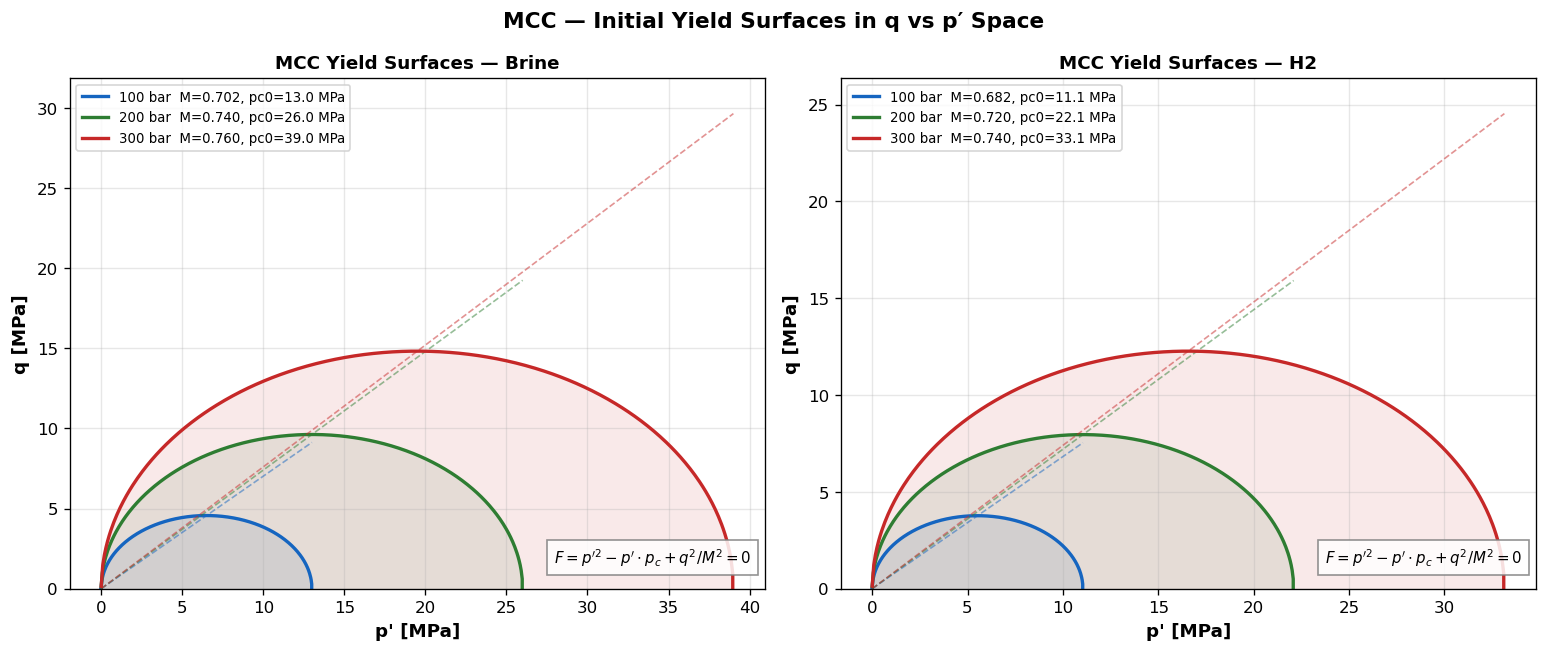

Fig 01 saved (yield surfaces) ✓


In [19]:
# =============================================================================
# CELL 09 — FIGURE 01: MCC YIELD SURFACES (INITIAL STATE)
# =============================================================================

# Create a 1×2 figure: left = Brine, right = H2
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

# Loop over each fluid type (one panel per fluid)
for ax, fluid in zip(axes, FLUIDS):

    # Loop over all three pressure levels
    for p_label in PRESSURES:
        g = table_guess[(fluid, p_label)]   # read MCC parameters for this case
        c = COLOR[p_label]                  # pressure-level colour

        # Compute the closed MCC yield ellipse
        py, qy = mcc_yield_surface(g['pc0_MPa'], g['M'])

        # Fill the ellipse with a translucent colour and draw the boundary
        ax.fill(py, qy, alpha=0.10, color=c)
        ax.plot(py, qy, lw=2.0, color=c,
                label=f"{p_label}  M={g['M']:.3f}, pc0={g['pc0_MPa']:.1f} MPa")

        # Plot the Critical State Line: q = M * p′
        pcsl = np.array([0, g['pc0_MPa']])
        ax.plot(pcsl, g['M'] * pcsl, '--', lw=1.0, color=c, alpha=0.5)

    # Axis labels and title
    ax.set_xlabel(PDASH_LABEL)
    ax.set_ylabel(Q_LABEL)
    ax.set_title(f'MCC Yield Surfaces — {fluid}')
    ax.set_ylim(bottom=0)              # q starts from zero (compression-positive)
    ax.legend(fontsize=8, loc='upper left')

    # Add yield-function equation as an annotation box
    ax.text(0.98, 0.05, r"$F = p'^2 - p'\cdot p_c + q^2/M^2 = 0$",
            transform=ax.transAxes, ha='right', fontsize=9,
            bbox=dict(fc='white', ec='grey', alpha=0.85, pad=4))

# Global figure title
fig.suptitle('MCC — Initial Yield Surfaces in q vs p′ Space',
             fontsize=13, fontweight='bold')

plt.tight_layout()
CELL_NAME = "Cell09"
save_fig('Fig01_YieldSurfaces')
plt.show()
print("Fig 01 saved (yield surfaces) ✓")


## Cell 10 — Figure 02: Yield Surfaces + Prescribed Stress Path

### What this cell produces
**Fig 02** — Yield surfaces overlaid with the **prescribed cyclic stress path** (p′, q).  
An arrow indicates the loading direction and a star marks the peak stress state.

### Interpretation
- The stress path is **identical for all cases** — it is a prescribed boundary condition.
- The path may lie inside or outside the initial yield surface, revealing which cases undergo **immediate plastic loading** (path pierces the ellipse).
- The diamond marker (◆) shows the initial stress state (Pᵢ, 0).

### Saved files
`Cell16_Fig02_YieldSurfaces_StressPath.pdf / .png`


  Saved → Outputs_Cyclic_MCCM_Clay_Rich/Cell10_Fig02_YieldSurfaces_StressPath.pdf
  Saved → Outputs_Cyclic_MCCM_Clay_Rich/Cell10_Fig02_YieldSurfaces_StressPath.png


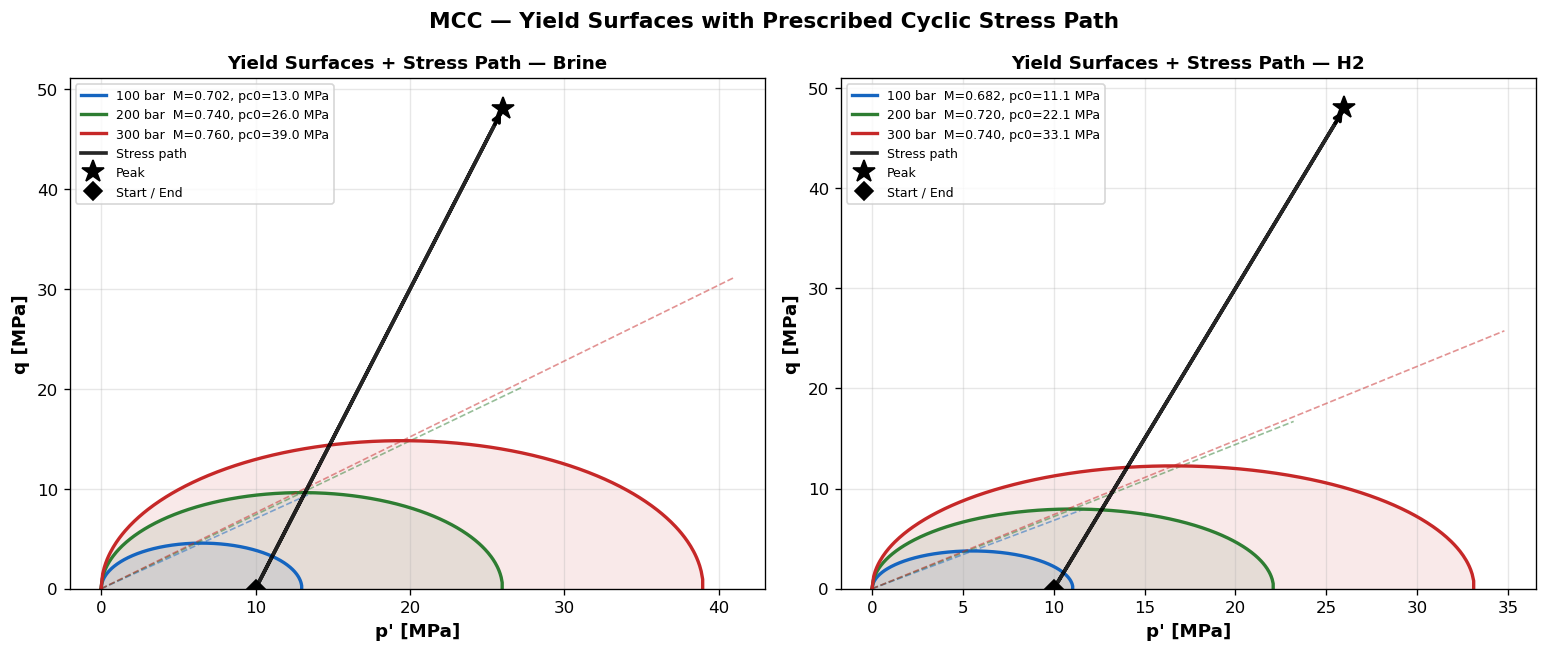

Fig 02 saved (yield surfaces + stress path) ✓


In [20]:
# =============================================================================
# CELL 10 — FIGURE 02: YIELD SURFACES + STRESS PATH
# =============================================================================

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))   # 1×2 layout: Brine | H2

for ax, fluid in zip(axes, FLUIDS):

    for p_label in PRESSURES:
        g = table_guess[(fluid, p_label)]   # MCC parameters
        c = COLOR[p_label]                  # colour

        # Yield surface
        py, qy = mcc_yield_surface(g['pc0_MPa'], g['M'])
        ax.fill(py, qy, alpha=0.10, color=c)
        ax.plot(py, qy, lw=2.0, color=c,
                label=f"{p_label}  M={g['M']:.3f}, pc0={g['pc0_MPa']:.1f} MPa")

        # CSL (extended slightly beyond pc0 for clarity)
        pcsl = np.array([0, g['pc0_MPa'] * 1.05])
        ax.plot(pcsl, g['M'] * pcsl, '--', lw=1.0, color=c, alpha=0.5)

    # Prescribed stress path overlay
    ax.plot(PP_SP, QP_SP, 'k-', lw=2.2, alpha=0.85, zorder=10,
            label='Stress path')

    # Peak stress point (star marker)
    ax.plot(PP_SP[HALF_SP], QP_SP[HALF_SP], 'k*', ms=14, zorder=11, label='Peak')

    # Initial stress point (diamond marker)
    ax.plot(Pi, 0, 'kD', ms=8, zorder=11, label='Start / End')

    # Arrow on loading branch to indicate direction
    ax.annotate('', xy=(PP_SP[HALF_SP],     QP_SP[HALF_SP]),
                    xytext=(PP_SP[HALF_SP-3], QP_SP[HALF_SP-3]),
                    arrowprops=dict(arrowstyle='->', color='k', lw=2.0))

    ax.set_xlabel(PDASH_LABEL)
    ax.set_ylabel(Q_LABEL)
    ax.set_title(f'Yield Surfaces + Stress Path — {fluid}')
    ax.set_ylim(bottom=0)
    ax.legend(fontsize=7.5, loc='upper left')

fig.suptitle('MCC — Yield Surfaces with Prescribed Cyclic Stress Path',
             fontsize=13, fontweight='bold')

plt.tight_layout()
CELL_NAME = "Cell10"
save_fig('Fig02_YieldSurfaces_StressPath')   # save to output folder
plt.show()
print("Fig 02 saved (yield surfaces + stress path) ✓")


## Cell 11 — Figure 03: Brine vs H₂ — Unified Yield Surfaces

### What this cell produces
**Fig 03** — A single panel comparing Brine (solid lines) and H₂ (dashed lines) yield surfaces at all three pressures, plus the stress path.

### Interpretation
- **Solid = Brine, Dashed = H₂** for each pressure color.
- At the same confining pressure, Brine has a **larger p_c0** (higher preconsolidation) and slightly higher M than H₂, reflecting different compaction histories or pore-fluid chemistry effects.
- The CSL (dotted) is plotted for the Brine parameters at each pressure.

### Saved files
`Cell16_Fig03_YieldSurfaces_BrineH2_Together.pdf / .png`


  Saved → Outputs_Cyclic_MCCM_Clay_Rich/Cell11_Fig03_YieldSurfaces_BrineH2_Together.pdf
  Saved → Outputs_Cyclic_MCCM_Clay_Rich/Cell11_Fig03_YieldSurfaces_BrineH2_Together.png


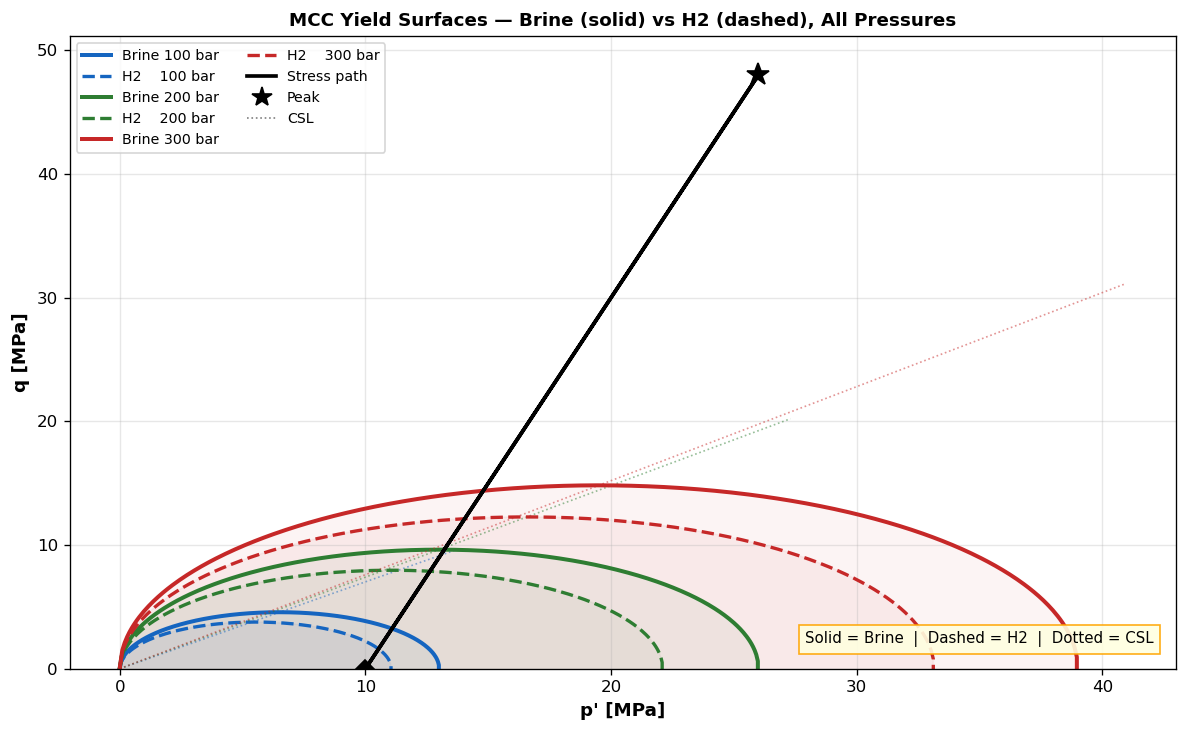

Fig 03 saved (Brine + H2 unified yield surfaces) ✓


In [21]:
# =============================================================================
# CELL 11 — FIGURE 03: BRINE vs H2 — UNIFIED YIELD SURFACES
# =============================================================================

fig, ax = plt.subplots(figsize=(10, 6.2))   # single-panel comparison

for p_label in PRESSURES:
    c = COLOR[p_label]                       # pressure color

    for fluid in FLUIDS:
        g  = table_guess[(fluid, p_label)]

        # Compute yield surface
        py, qy = mcc_yield_surface(g['pc0_MPa'], g['M'])

        # Solid line for Brine, dashed for H2
        ls = '-'  if fluid == 'Brine' else '--'
        lw = 2.4  if fluid == 'Brine' else 2.0

        ax.plot(py, qy, ls, lw=lw, color=c,
                label=f"{fluid} {p_label}  M={g['M']:.3f}")
        ax.fill(py, qy, alpha=0.05, color=c)

    # CSL based on Brine parameters at this pressure
    M_b  = table_guess[('Brine', p_label)]['M']
    pc_b = table_guess[('Brine', p_label)]['pc0_MPa']
    ax.plot([0, pc_b * 1.05], [0, M_b * pc_b * 1.05],
            ':', lw=1.0, color=c, alpha=0.5)

# Prescribed stress path
ax.plot(PP_SP, QP_SP, 'k-', lw=2.2, zorder=10, label='Stress path')
ax.plot(PP_SP[HALF_SP], QP_SP[HALF_SP], 'k*', ms=14, zorder=11, label='Peak')
ax.plot(Pi, 0, 'kD', ms=8, zorder=11, label='Start/End')

ax.set_xlabel(PDASH_LABEL)
ax.set_ylabel(Q_LABEL)
ax.set_title('MCC Yield Surfaces — Brine (solid) vs H2 (dashed), All Pressures',
             fontweight='bold')
ax.set_ylim(bottom=0)

# Custom legend — build manually to avoid duplicate entries
leg_els = []
for p_label in PRESSURES:
    c = COLOR[p_label]
    leg_els += [
        Line2D([0], [0], color=c, lw=2.4, ls='-',  label=f'Brine {p_label}'),
        Line2D([0], [0], color=c, lw=2.0, ls='--', label=f'H2    {p_label}'),
    ]
leg_els += [
    Line2D([0], [0], color='k', lw=2.2,                  label='Stress path'),
    Line2D([0], [0], color='k', lw=0, marker='*', ms=12, label='Peak'),
    Line2D([0], [0], color='k', lw=1.0, ls=':', alpha=0.5, label='CSL'),
]
ax.legend(handles=leg_els, ncol=2, fontsize=8.5, loc='upper left')

# Annotation box
ax.text(0.98, 0.04, 'Solid = Brine  |  Dashed = H2  |  Dotted = CSL',
        transform=ax.transAxes, ha='right', fontsize=9,
        bbox=dict(fc='lightyellow', ec='orange', alpha=0.9, pad=4))

plt.tight_layout()
CELL_NAME = "Cell11"
save_fig('Fig03_YieldSurfaces_BrineH2_Together')
plt.show()
print("Fig 03 saved (Brine + H2 unified yield surfaces) ✓")


## Cell 12 — Figure 04: Cyclic Stress Path + Evolving Yield Surfaces (per fluid)

### What this cell produces
**Fig 04** — Two separate figures (one per fluid), each with **1×3 panels** showing the yield surface at **Cycle 1** (dashed) and **Cycle 8** (solid), together with the stress path and CSL.

### Interpretation
- The outward shift of the solid ellipse from the dashed ellipse quantifies **isotropic hardening** over 8 cycles.
- Greater expansion at 300 bar confirms the pressure-dependence of the hardening rate.
- The CSL (dotted grey) is plotted at the Cycle-8 p_c to show proximity to critical state.

### Saved files
`Cell16_Fig04_CyclicStressPath.pdf / .png` (saved twice — once per fluid)


  Saved → Outputs_Cyclic_MCCM_Clay_Rich/Cell12_Fig04_CyclicStressPath.pdf
  Saved → Outputs_Cyclic_MCCM_Clay_Rich/Cell12_Fig04_CyclicStressPath.png


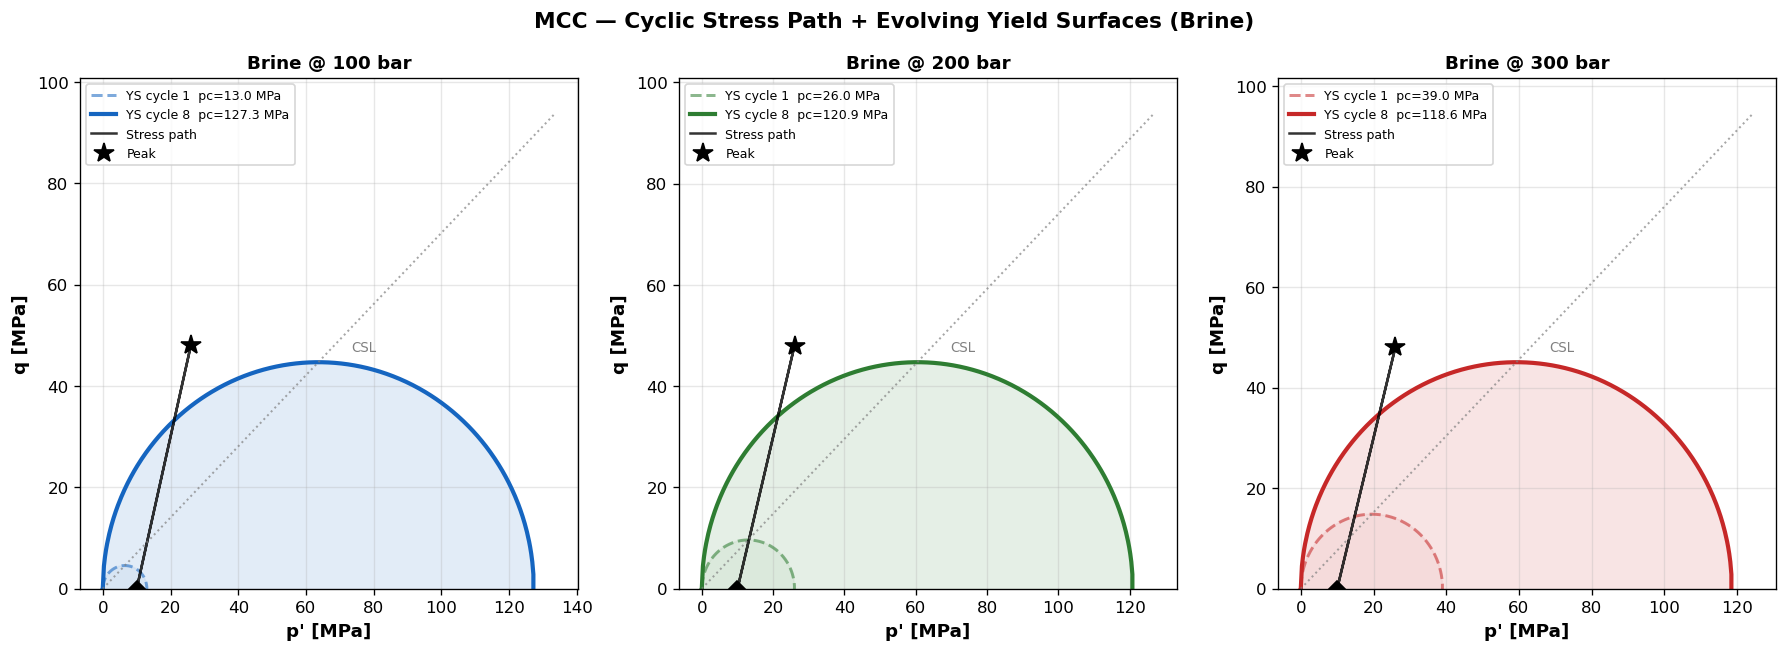

Fig 04 (Brine) saved ✓
  Saved → Outputs_Cyclic_MCCM_Clay_Rich/Cell12_Fig04_CyclicStressPath.pdf
  Saved → Outputs_Cyclic_MCCM_Clay_Rich/Cell12_Fig04_CyclicStressPath.png


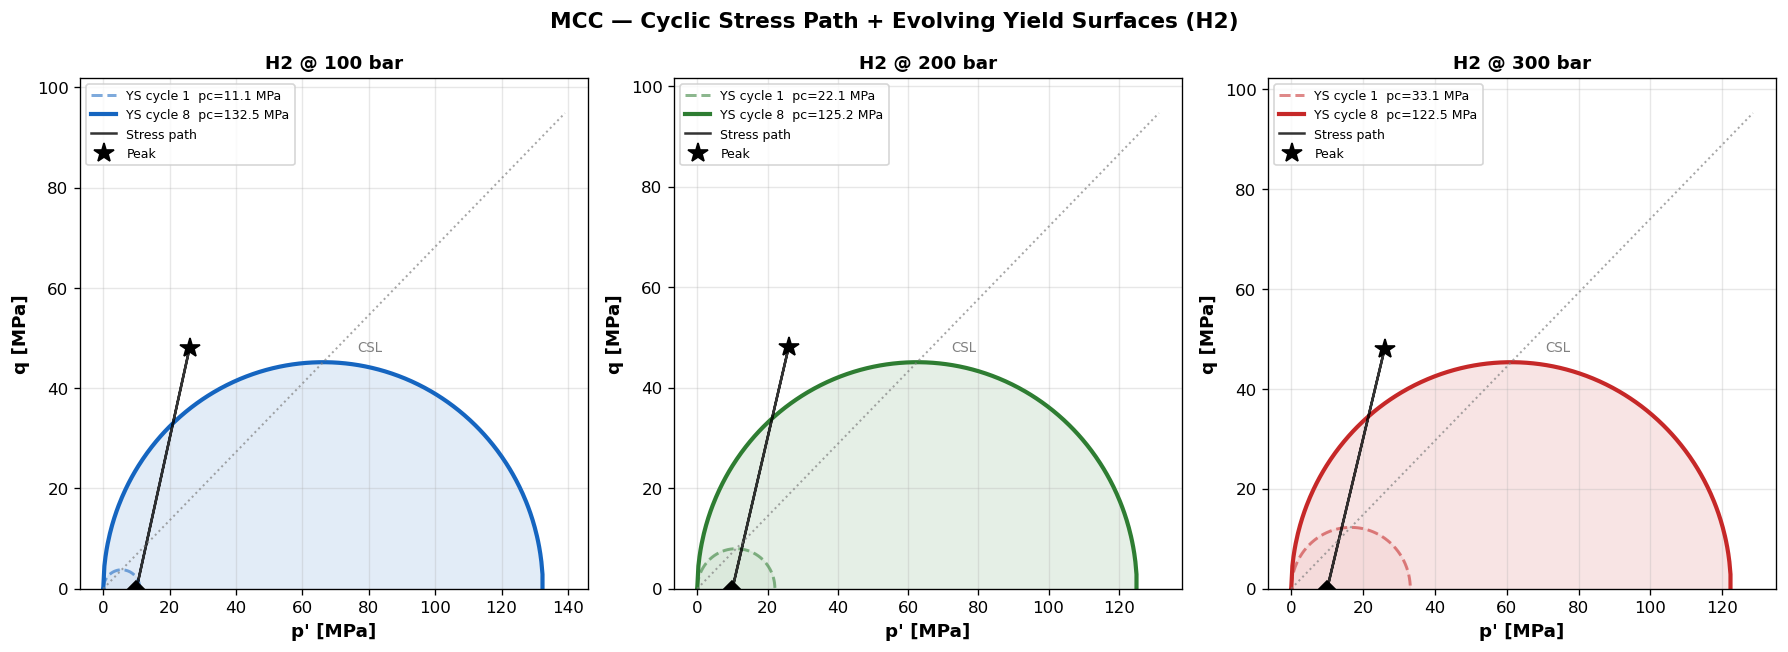

Fig 04 (H2) saved ✓


In [22]:
# =============================================================================
# CELL 12 — FIGURE 04: CYCLIC STRESS PATH + EVOLVING YIELD SURFACES (PER FLUID)
# =============================================================================

for fluid_solo in FLUIDS:    # one full figure per fluid type

    fig, axes = plt.subplots(1, 3, figsize=(15, 5.5))   # 1×3 layout

    for col, p_label in enumerate(PRESSURES):
        ax  = axes[col]
        sim = SIM[(fluid_solo, p_label)]   # simulation results
        c   = COLOR[p_label]

        # Yield surface at Cycle 1 (initial pc0) — dashed
        py1, qy1 = mcc_yield_surface(sim['pc0'], sim['M'])
        ax.plot(py1, qy1, '--', lw=1.8, color=c, alpha=0.55,
                label=f"YS cycle 1  pc={sim['pc0']:.1f} MPa")
        ax.fill(py1, qy1, alpha=0.05, color=c)

        # Yield surface at Cycle 8 (final pc) — solid
        py8, qy8 = mcc_yield_surface(sim['pc_cyc'][-1], sim['M'])
        ax.plot(py8, qy8, '-', lw=2.5, color=c,
                label=f"YS cycle 8  pc={sim['pc_cyc'][-1]:.1f} MPa")
        ax.fill(py8, qy8, alpha=0.12, color=c)

        # Prescribed stress path
        ax.plot(PP_SP, QP_SP, 'k-', lw=1.5, alpha=0.8, label='Stress path')
        ax.plot(PP_SP[HALF_SP], QP_SP[HALF_SP], 'k*', ms=12, label='Peak')
        ax.plot(Pi, 0, 'kD', ms=7)    # initial stress point

        # CSL at Cycle-8 pc
        pcsl2 = np.array([0, sim['pc_cyc'][-1] * 1.05])
        ax.plot(pcsl2, sim['M'] * pcsl2, ':', lw=1.2, color='grey', alpha=0.7)
        ax.text(pcsl2[-1] * 0.55, sim['M'] * pcsl2[-1] * 0.50,
                'CSL', fontsize=8, color='grey')

        ax.set_xlabel(PDASH_LABEL)
        ax.set_ylabel(Q_LABEL)
        ax.set_title(f'{fluid_solo} @ {p_label}')
        ax.set_ylim(bottom=0)
        ax.legend(fontsize=7.5, loc='upper left')

    fig.suptitle(f'MCC — Cyclic Stress Path + Evolving Yield Surfaces ({fluid_solo})',
                 fontsize=13, fontweight='bold')

    plt.tight_layout()
    CELL_NAME = "Cell12"
    save_fig('Fig04_CyclicStressPath')   # saved for each fluid iteration
    plt.show()
    print(f"Fig 04 ({fluid_solo}) saved ✓")


## Cell 13 — Figure 05: Cyclic Stress Path — Brine + H₂ Together

### What this cell produces
**Fig 05** — Three panels (one per pressure), each showing Brine (solid) and H₂ (dashed) yield surfaces at Cycles 1 and 8, together with the stress path.

### Interpretation
- Direct fluid-type comparison at the same confining pressure.
- H₂ cases consistently show **slightly smaller yield surfaces** due to lower p_c0 values.
- Both fluids exhibit comparable hardening rates (θ is the same), so ellipse expansion is driven purely by the initial p_c0 difference.

### Saved files
`Cell16_Fig05_CyclicStressPath_BrineH2_Together.pdf / .png`


  Saved → Outputs_Cyclic_MCCM_Clay_Rich/Cell13_Fig05_CyclicStressPath_BrineH2_Together.pdf
  Saved → Outputs_Cyclic_MCCM_Clay_Rich/Cell13_Fig05_CyclicStressPath_BrineH2_Together.png


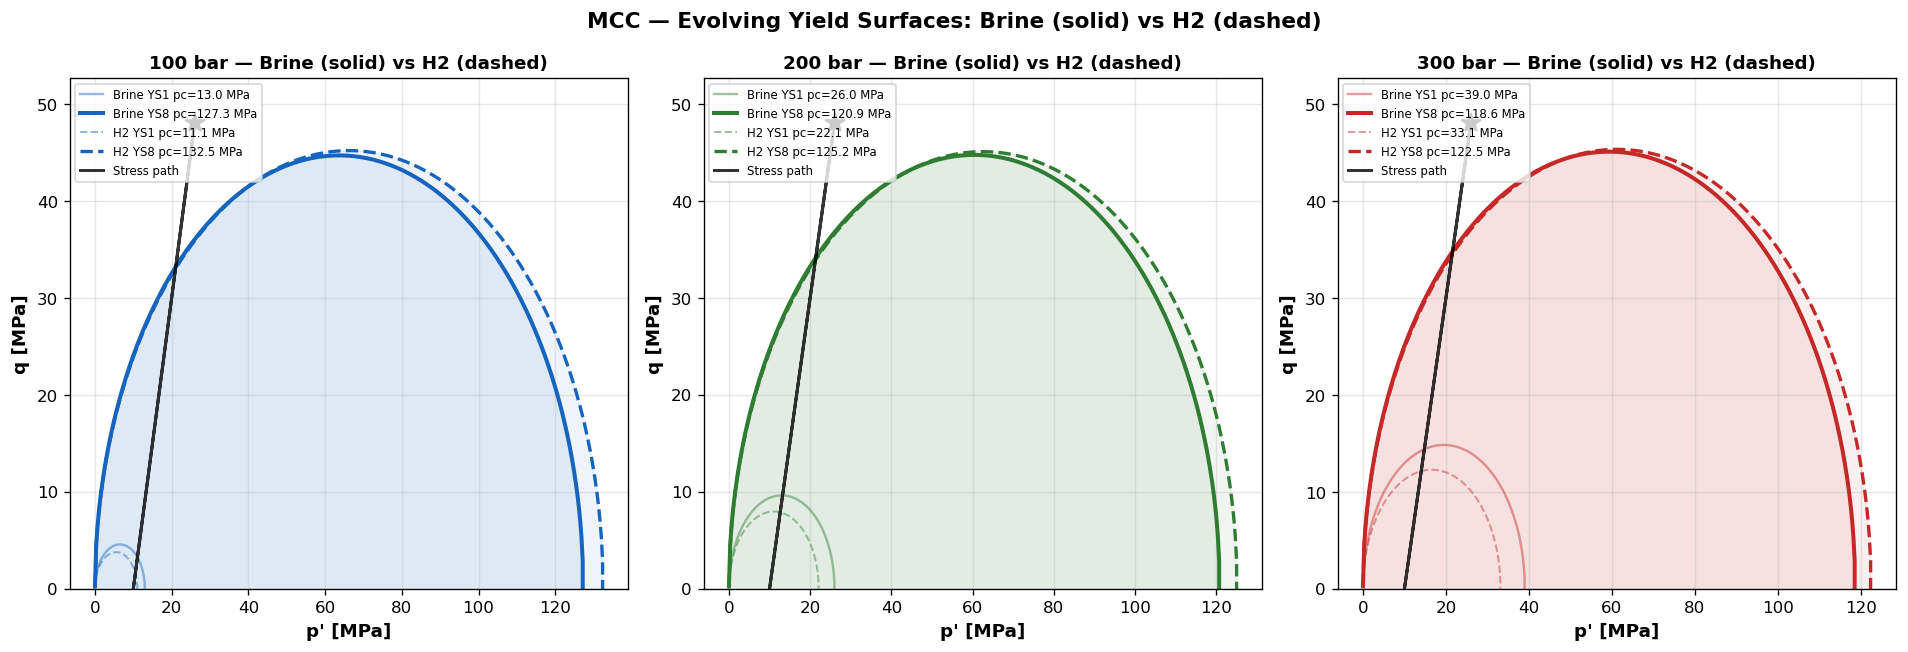

Fig 05 saved (Brine + H2 cyclic stress path unified) ✓


In [23]:
# =============================================================================
# CELL 13 — FIGURE 05: BRINE + H2 CYCLIC STRESS PATH TOGETHER
# =============================================================================

fig, axes = plt.subplots(1, 3, figsize=(16, 5.5))   # 1×3 layout

for col, p_label in enumerate(PRESSURES):
    ax = axes[col]
    c  = COLOR[p_label]

    for fluid in FLUIDS:
        sim = SIM[(fluid, p_label)]

        # Line style: solid for Brine, dashed for H2
        ls = '-'  if fluid == 'Brine' else '--'
        lw = 2.4  if fluid == 'Brine' else 2.0

        # Cycle-1 yield surface (thin)
        py1, qy1 = mcc_yield_surface(sim['pc0'], sim['M'])
        ax.plot(py1, qy1, ls, lw=lw * 0.6, color=c, alpha=0.45,
                label=f"{fluid} YS1 pc={sim['pc0']:.1f} MPa")

        # Cycle-8 yield surface (full weight)
        py8, qy8 = mcc_yield_surface(sim['pc_cyc'][-1], sim['M'])
        ax.plot(py8, qy8, ls, lw=lw, color=c,
                label=f"{fluid} YS8 pc={sim['pc_cyc'][-1]:.1f} MPa")
        ax.fill(py8, qy8, alpha=0.07, color=c)

    # Stress path
    ax.plot(PP_SP, QP_SP, 'k-', lw=1.8, alpha=0.8, label='Stress path')
    ax.plot(PP_SP[HALF_SP], QP_SP[HALF_SP], 'k*', ms=12)

    ax.set_xlabel(PDASH_LABEL)
    ax.set_ylabel(Q_LABEL)
    ax.set_title(f'{p_label} — Brine (solid) vs H2 (dashed)')
    ax.set_ylim(bottom=0)
    ax.legend(fontsize=7, loc='upper left')

fig.suptitle('MCC — Evolving Yield Surfaces: Brine (solid) vs H2 (dashed)',
             fontsize=13, fontweight='bold')

plt.tight_layout()
CELL_NAME = "Cell13"
save_fig('Fig05_CyclicStressPath_BrineH2_Together')
plt.show()
print("Fig 05 saved (Brine + H2 cyclic stress path unified) ✓")


## Cell 14 — Figure 06: Single-Cycle Stress–Strain Loop (per fluid)

### What this cell produces
**Fig 06** — Two figures (Brine, then H₂), each with **1×3 panels**, showing the **q vs accumulated inelastic strain** loop for Cycle 1 only.

### Interpretation
- The filled area under each curve represents the **plastic work dissipated** in the first cycle.
- Circle (●) = start of cycle; square (■) = end of cycle.
- The text annotation shows the cycle-1 inelastic strain magnitude.
- Higher-pressure cases accumulate more strain in the first cycle due to stronger initial plastic loading.

### Saved files
`Cell16_Fig06_SingleCycleLoop.pdf / .png` (saved twice — once per fluid)


  Saved → Outputs_Cyclic_MCCM_Clay_Rich/Cell14_Fig06_SingleCycleLoop.pdf
  Saved → Outputs_Cyclic_MCCM_Clay_Rich/Cell14_Fig06_SingleCycleLoop.png


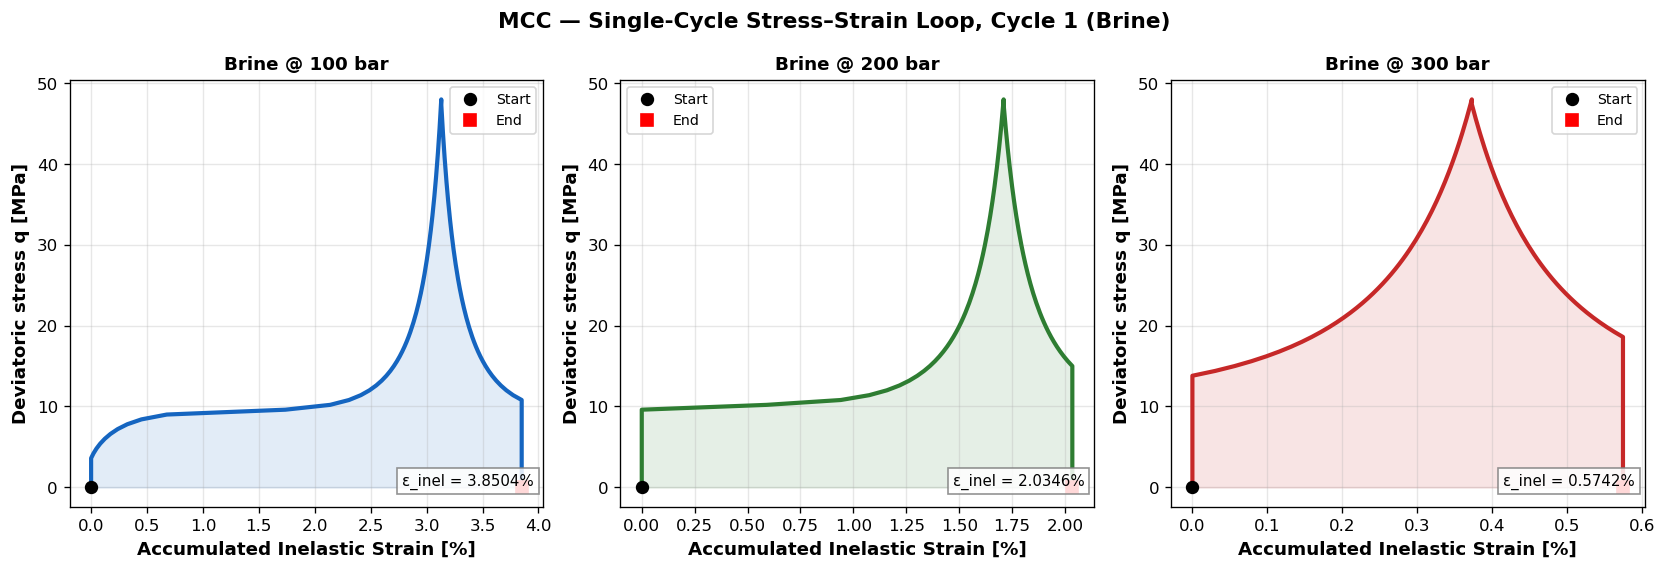

Fig 06 (Brine) single-cycle loop saved ✓
  Saved → Outputs_Cyclic_MCCM_Clay_Rich/Cell14_Fig06_SingleCycleLoop.pdf
  Saved → Outputs_Cyclic_MCCM_Clay_Rich/Cell14_Fig06_SingleCycleLoop.png


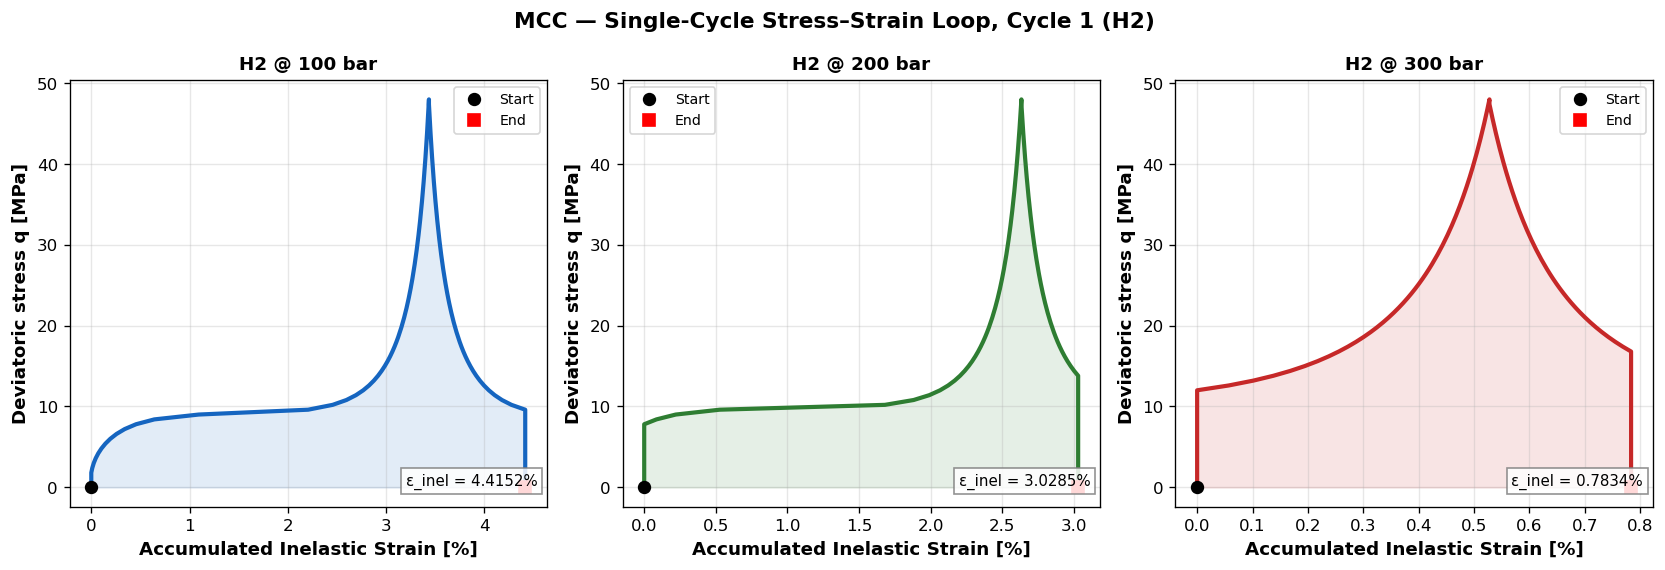

Fig 06 (H2) single-cycle loop saved ✓


In [24]:
# =============================================================================
# CELL 14 — FIGURE 06: SINGLE-CYCLE STRESS-STRAIN LOOP (PER FLUID)
# =============================================================================

for fluid_solo in FLUIDS:    # one figure per fluid

    fig, axes = plt.subplots(1, 3, figsize=(14, 4.8))   # 1×3 layout

    for col, p_label in enumerate(PRESSURES):
        ax  = axes[col]
        sim = SIM[(fluid_solo, p_label)]
        c   = COLOR[p_label]

        # Cycle-1 strain and deviatoric stress arrays (convert strain to %)
        eps = sim['eps_c1'] * 100   # accumulated inelastic strain [%]
        q   = sim['q_c1']           # corresponding q values [MPa]

        # Plot the hysteretic loop with a filled area
        ax.plot(eps, q, '-', lw=2.5, color=c)
        ax.fill_between(eps, 0, q, alpha=0.12, color=c)

        # Mark start (circle) and end (square) of the cycle
        ax.plot(eps[0],  q[0],  'ko', ms=7, label='Start')
        ax.plot(eps[-1], q[-1], 'rs', ms=7, label='End')

        # Annotate with cycle-1 inelastic strain magnitude
        e_i = sim['e_per'][0] * 100
        ax.text(0.98, 0.05, f'ε_inel = {e_i:.4f}%',
                transform=ax.transAxes, ha='right', fontsize=9,
                bbox=dict(fc='white', ec='grey', alpha=0.85, pad=3))

        ax.set_xlabel('Accumulated Inelastic Strain [%]')
        ax.set_ylabel('Deviatoric stress q [MPa]')
        ax.set_title(f'{fluid_solo} @ {p_label}')
        ax.legend(fontsize=8.5)

    fig.suptitle(f'MCC — Single-Cycle Stress–Strain Loop, Cycle 1 ({fluid_solo})',
                 fontsize=13, fontweight='bold')

    plt.tight_layout()
    CELL_NAME = "Cell14"
    save_fig('Fig06_SingleCycleLoop')
    plt.show()
    print(f"Fig 06 ({fluid_solo}) single-cycle loop saved ✓")


## Cell 15 — Figure 07: Single-Cycle Loop — Brine + H₂ Together

### What this cell produces
**Fig 07** — Three panels (one per pressure), directly comparing Brine vs H₂ Cycle-1 loops on the same axes.

### Interpretation
- H₂ loops are consistently **offset to slightly higher strains** because of their lower initial p_c0 (softer material).
- The shape of both loops is similar, confirming that the cyclic kinematics are governed more by the stress path than the fluid type.

### Saved files
`Cell16_Fig07_SingleCycleLoop_BrineH2_Together.pdf / .png`


  Saved → Outputs_Cyclic_MCCM_Clay_Rich/Cell15_Fig07_SingleCycleLoop_BrineH2_Together.pdf
  Saved → Outputs_Cyclic_MCCM_Clay_Rich/Cell15_Fig07_SingleCycleLoop_BrineH2_Together.png


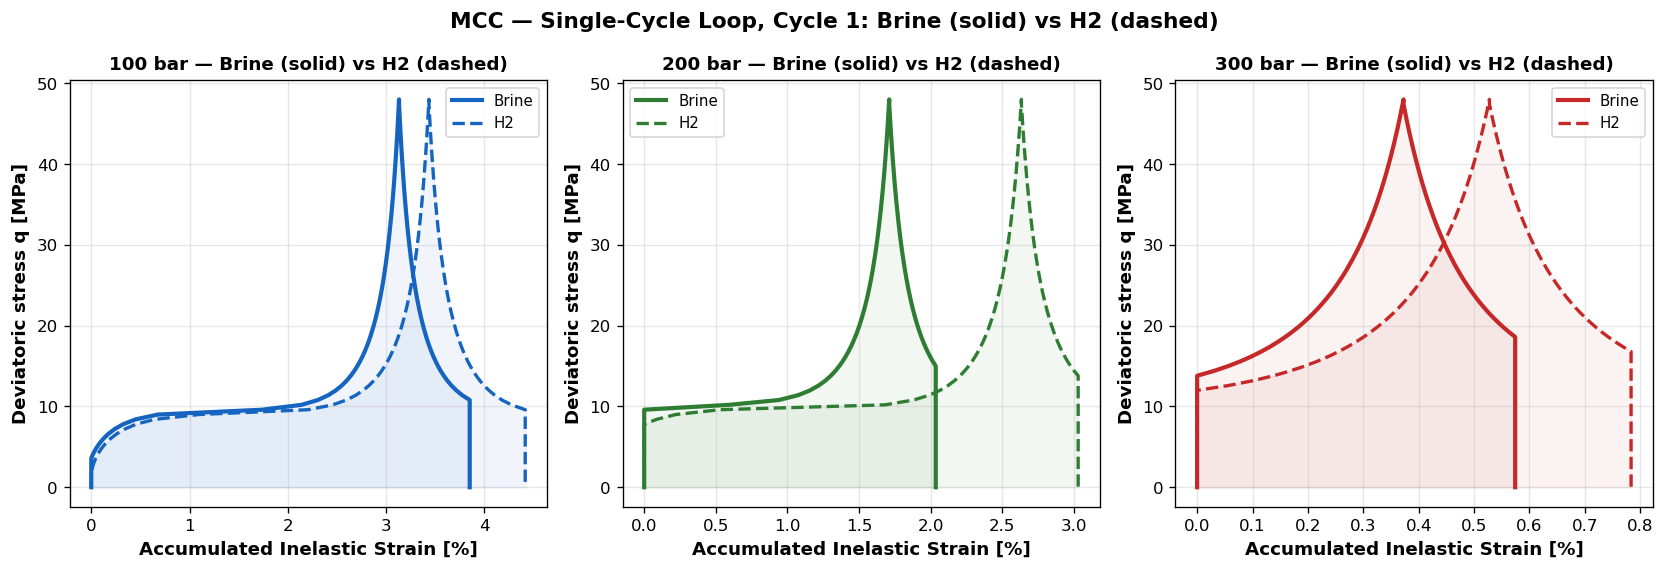

Fig 07 saved (Brine + H2 unified single-cycle loop) ✓


In [25]:
# =============================================================================
# CELL 15 — FIGURE 07: SINGLE-CYCLE LOOP — BRINE + H2 TOGETHER
# =============================================================================

fig, axes = plt.subplots(1, 3, figsize=(14, 4.8))   # 1×3 layout

for col, p_label in enumerate(PRESSURES):
    ax = axes[col]
    c  = COLOR[p_label]

    for fluid in FLUIDS:
        sim = SIM[(fluid, p_label)]

        ls = '-'  if fluid == 'Brine' else '--'
        lw = 2.5  if fluid == 'Brine' else 2.0

        eps = sim['eps_c1'] * 100   # cycle-1 strain [%]
        q   = sim['q_c1']           # cycle-1 q [MPa]

        ax.plot(eps, q, ls, lw=lw, color=c, label=fluid)
        ax.fill_between(eps, 0, q, alpha=0.06, color=c)

    ax.set_xlabel('Accumulated Inelastic Strain [%]')
    ax.set_ylabel('Deviatoric stress q [MPa]')
    ax.set_title(f'{p_label} — Brine (solid) vs H2 (dashed)')
    ax.legend(fontsize=9)

fig.suptitle('MCC — Single-Cycle Loop, Cycle 1: Brine (solid) vs H2 (dashed)',
             fontsize=13, fontweight='bold')

plt.tight_layout()
CELL_NAME = "Cell15"
save_fig('Fig07_SingleCycleLoop_BrineH2_Together')
plt.show()
print("Fig 07 saved (Brine + H2 unified single-cycle loop) ✓")


## Cell 16 — Figure 08: Cumulative Inelastic Strain vs Cycle Number

### What this cell produces
**Fig 08** — A single panel with all six cases, showing how **cumulative inelastic strain** grows over 8 cycles.

### Interpretation
- **Solid lines** = Brine; **dashed lines** = H₂; marker fill indicates fluid (filled ● = Brine, open △ = H₂).
- The **flattening of the curves** in later cycles is evidence of **cyclic hardening** (each cycle adds less strain than the previous one).
- Higher pressure → steeper initial slope → more cumulative damage.

### Saved files
`Cell16_Fig08_CumulativeStrain.pdf / .png`


  Saved → Outputs_Cyclic_MCCM_Clay_Rich/Cell16_Fig08_CumulativeStrain.pdf
  Saved → Outputs_Cyclic_MCCM_Clay_Rich/Cell16_Fig08_CumulativeStrain.png


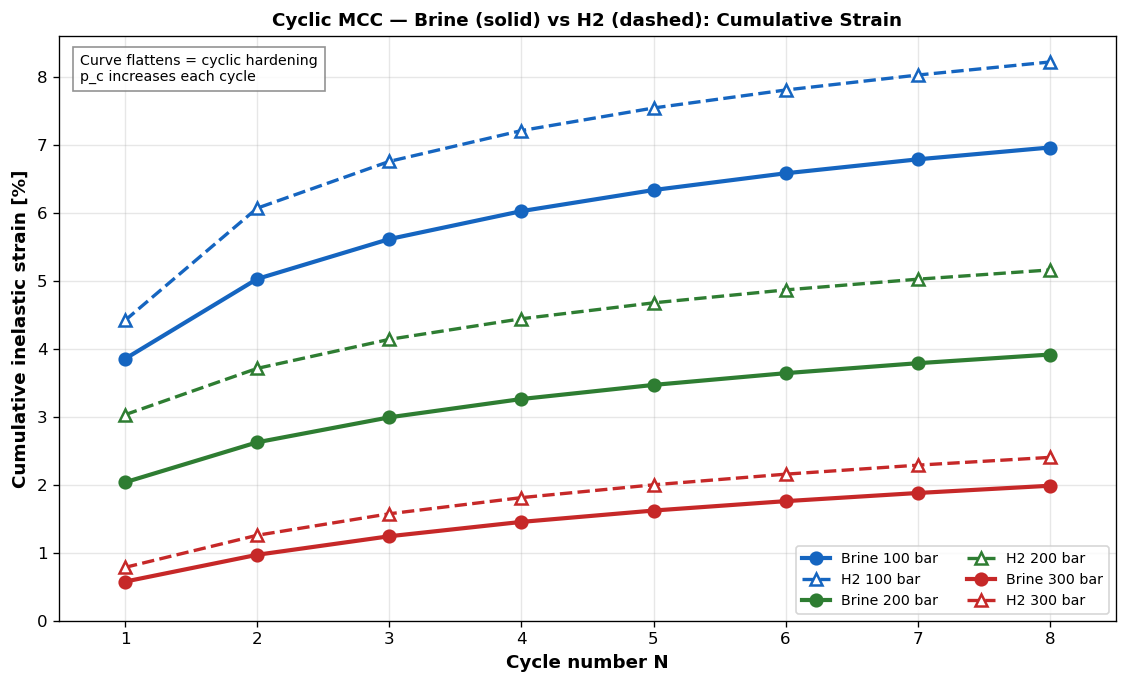

Fig 08 saved (cumulative strain) ✓


In [26]:
# =============================================================================
# CELL 16 — FIGURE 08: CUMULATIVE INELASTIC STRAIN vs CYCLE NUMBER
# =============================================================================

fig, ax = plt.subplots(figsize=(9.5, 5.8))   # single-panel figure
leg_els = []                                  # list for custom legend entries

for p_label in PRESSURES:
    c = COLOR[p_label]

    for fluid in FLUIDS:
        sim = SIM[(fluid, p_label)]

        ls  = '-'     if fluid == 'Brine' else '--'
        lw  = 2.5     if fluid == 'Brine' else 2.0
        mk  = 'o'     if fluid == 'Brine' else '^'
        mfc = c       if fluid == 'Brine' else 'white'    # filled vs open marker

        # Plot cumulative strain [%] vs cycle number
        ax.plot(CYC, sim['e_cum'] * 100, ls + mk, lw=lw, ms=7,
                color=c, mfc=mfc, mew=1.5)

        # Build matching legend handle
        leg_els.append(Line2D([0], [0], color=c, lw=lw, ls=ls,
                               marker=mk, ms=7, mfc=mfc, mew=1.5,
                               label=f'{fluid} {p_label}'))

ax.set_xlabel('Cycle number N')
ax.set_ylabel(SUM_LABEL)
ax.set_title('Cyclic MCC — Brine (solid) vs H2 (dashed): Cumulative Strain',
             fontweight='bold')

ax.xaxis.set_major_locator(mticker.MultipleLocator(1))  # integer cycle ticks
ax.set_xlim(0.5, 8.5)
ax.set_ylim(bottom=0)

ax.legend(handles=leg_els, ncol=2, fontsize=8.5, loc='lower right')

# Annotation note about hardening
ax.text(0.02, 0.97,
        """Curve flattens = cyclic hardening
p_c increases each cycle""",
        transform=ax.transAxes, va='top', fontsize=8.5,
        bbox=dict(fc='white', ec='grey', alpha=0.85, pad=4))

plt.tight_layout()
CELL_NAME = "Cell16"
save_fig('Fig08_CumulativeStrain')
plt.show()
print("Fig 08 saved (cumulative strain) ✓")


## Cell 17 — Figure 09: Per-Cycle Inelastic Strain Increment

### What this cell produces
**Fig 09** — Three panels showing the **per-cycle strain increment** (strain added in each individual cycle) as a function of cycle number.

### Interpretation
- A monotonically **decreasing** per-cycle increment confirms progressive hardening — the material becomes stiffer cycle by cycle.
- Brine and H₂ exhibit similar decay trends, but Brine starts slightly lower due to the higher initial p_c0.
- At 300 bar, the increments are larger, confirming pressure-dependent plastic response.

### Saved files
`Cell16_Fig09_PerCycleStrain.pdf / .png`


  Saved → Outputs_Cyclic_MCCM_Clay_Rich/Cell17_Fig09_PerCycleStrain.pdf
  Saved → Outputs_Cyclic_MCCM_Clay_Rich/Cell17_Fig09_PerCycleStrain.png


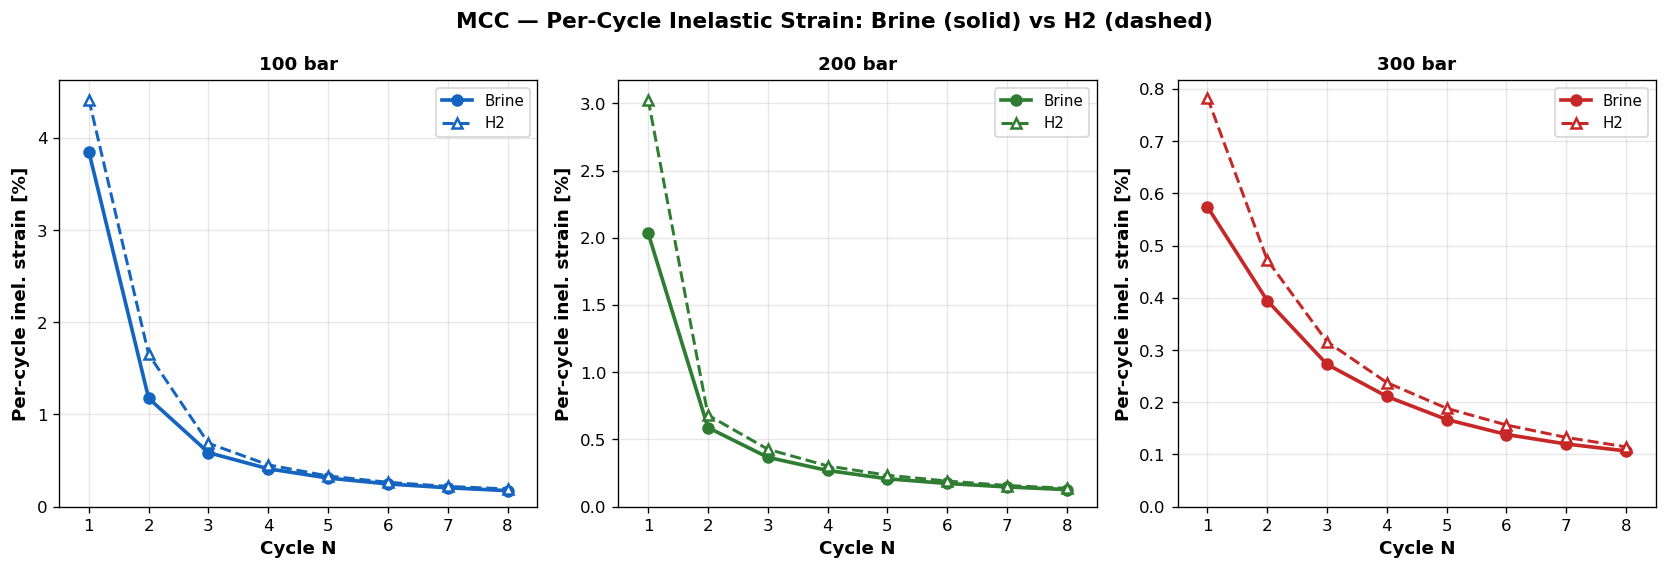

Fig 09 saved (per-cycle increments) ✓


In [27]:
# =============================================================================
# CELL 17 — FIGURE 09: PER-CYCLE INELASTIC STRAIN INCREMENT
# =============================================================================

fig, axes = plt.subplots(1, 3, figsize=(14, 4.8))   # 1×3 layout

for col, p_label in enumerate(PRESSURES):
    ax = axes[col]
    c  = COLOR[p_label]

    for fluid in FLUIDS:
        sim = SIM[(fluid, p_label)]

        ls  = '-'   if fluid == 'Brine' else '--'
        lw  = 2.2   if fluid == 'Brine' else 1.8
        mk  = 'o'   if fluid == 'Brine' else '^'
        mfc = c     if fluid == 'Brine' else 'white'

        # Per-cycle strain increment [%] vs cycle number
        ax.plot(CYC, sim['e_per'] * 100, ls + mk, lw=lw, ms=6,
                color=c, mfc=mfc, mew=1.5, label=fluid)

    ax.set_xlabel('Cycle N')
    ax.set_ylabel('Per-cycle inel. strain [%]')
    ax.set_title(f'{p_label}')
    ax.xaxis.set_major_locator(mticker.MultipleLocator(1))
    ax.set_xlim(0.5, 8.5)
    ax.set_ylim(bottom=0)
    ax.legend(fontsize=9)

fig.suptitle('MCC — Per-Cycle Inelastic Strain: Brine (solid) vs H2 (dashed)',
             fontsize=13, fontweight='bold')

plt.tight_layout()
CELL_NAME = "Cell17"
save_fig('Fig09_PerCycleStrain')
plt.show()
print("Fig 09 saved (per-cycle increments) ✓")


## Cell 18 — Figure 10: Preconsolidation Pressure Evolution

### What this cell produces
**Fig 10** — Three panels showing **p_c evolution** over 8 cycles for all fluids at each pressure level.

### Governing hardening law (shown here)
$$p_c^{j+1} = p_c^j \exp\!\left(\frac{1+e}{\lambda - \kappa}\, d\varepsilon_v^p\right)$$

### Interpretation
- p_c increases monotonically — the yield surface **expands** with every cycle (isotropic hardening).
- The dotted horizontal line marks the **initial p_c0** for reference.
- The rate of increase diminishes over cycles, consistent with decreasing per-cycle plastic strain.

### Saved files
`Cell16_Fig10_PcEvolution.pdf / .png`


  Saved → Outputs_Cyclic_MCCM_Clay_Rich/Cell18_Fig10_PcEvolution.pdf
  Saved → Outputs_Cyclic_MCCM_Clay_Rich/Cell18_Fig10_PcEvolution.png


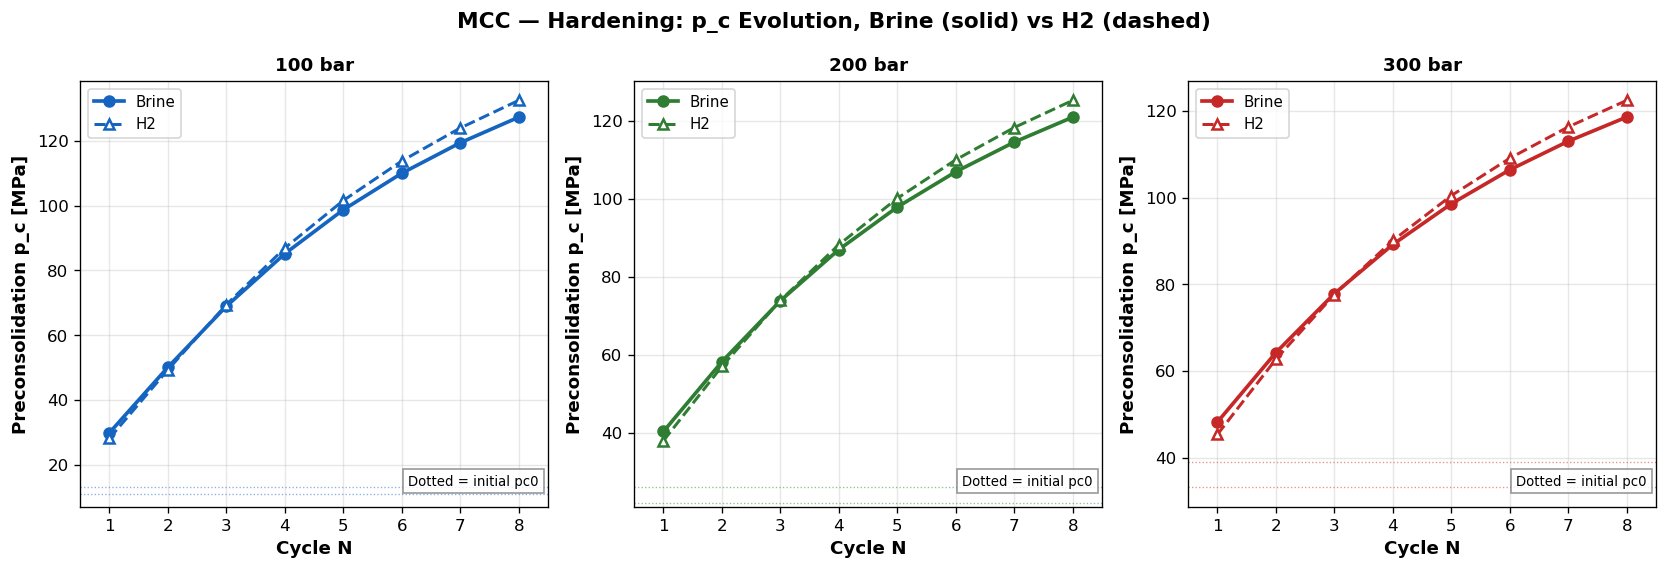

Fig 10 saved (p_c evolution) ✓


In [28]:
# =============================================================================
# CELL 18 — FIGURE 10: PRECONSOLIDATION PRESSURE EVOLUTION
# =============================================================================

fig, axes = plt.subplots(1, 3, figsize=(14, 4.8))   # 1×3 layout

for col, p_label in enumerate(PRESSURES):
    ax = axes[col]
    c  = COLOR[p_label]

    for fluid in FLUIDS:
        sim = SIM[(fluid, p_label)]

        ls  = '-'   if fluid == 'Brine' else '--'
        lw  = 2.2   if fluid == 'Brine' else 1.8
        mk  = 'o'   if fluid == 'Brine' else '^'
        mfc = c     if fluid == 'Brine' else 'white'

        # Plot preconsolidation pressure [MPa] vs cycle number
        ax.plot(CYC, sim['pc_cyc'], ls + mk, lw=lw, ms=6,
                color=c, mfc=mfc, mew=1.5, label=fluid)

        # Reference dotted line at initial pc0
        ax.axhline(sim['pc0'], color=c, lw=0.8, ls=':', alpha=0.5)

    ax.set_xlabel('Cycle N')
    ax.set_ylabel(PC_LABEL)
    ax.set_title(f'{p_label}')
    ax.xaxis.set_major_locator(mticker.MultipleLocator(1))
    ax.set_xlim(0.5, 8.5)
    ax.legend(fontsize=9)

    ax.text(0.98, 0.05, 'Dotted = initial pc0',
            transform=ax.transAxes, ha='right', fontsize=8,
            bbox=dict(fc='white', ec='grey', alpha=0.8, pad=3))

fig.suptitle('MCC — Hardening: p_c Evolution, Brine (solid) vs H2 (dashed)',
             fontsize=13, fontweight='bold')

plt.tight_layout()
CELL_NAME = "Cell18"
save_fig('Fig10_PcEvolution')
plt.show()
print("Fig 10 saved (p_c evolution) ✓")


## Cell 19 — Figure 11: Void Ratio Evolution

### What this cell produces
**Fig 11** — Void ratio e vs cycle number for all cases.

### Physical basis
$$e = \frac{\phi}{1-\phi}, \qquad \Delta e = -(1+e)\kappa \ln\!\left(\frac{p_c^{new}}{p_{c0}}\right)$$

### Interpretation
- Void ratio **decreases monotonically** as the material compacts under cyclic loading.
- Lower initial porosity (Brine at 300 bar) → smaller absolute changes.
- The dotted line marks the initial e₀ for reference.
- Reduction in void ratio directly drives the permeability decrease shown in Fig 12.

### Saved files
`Cell16_Fig11_VoidRatio.pdf / .png`


  Saved → Outputs_Cyclic_MCCM_Clay_Rich/Cell19_Fig11_VoidRatio.pdf
  Saved → Outputs_Cyclic_MCCM_Clay_Rich/Cell19_Fig11_VoidRatio.png


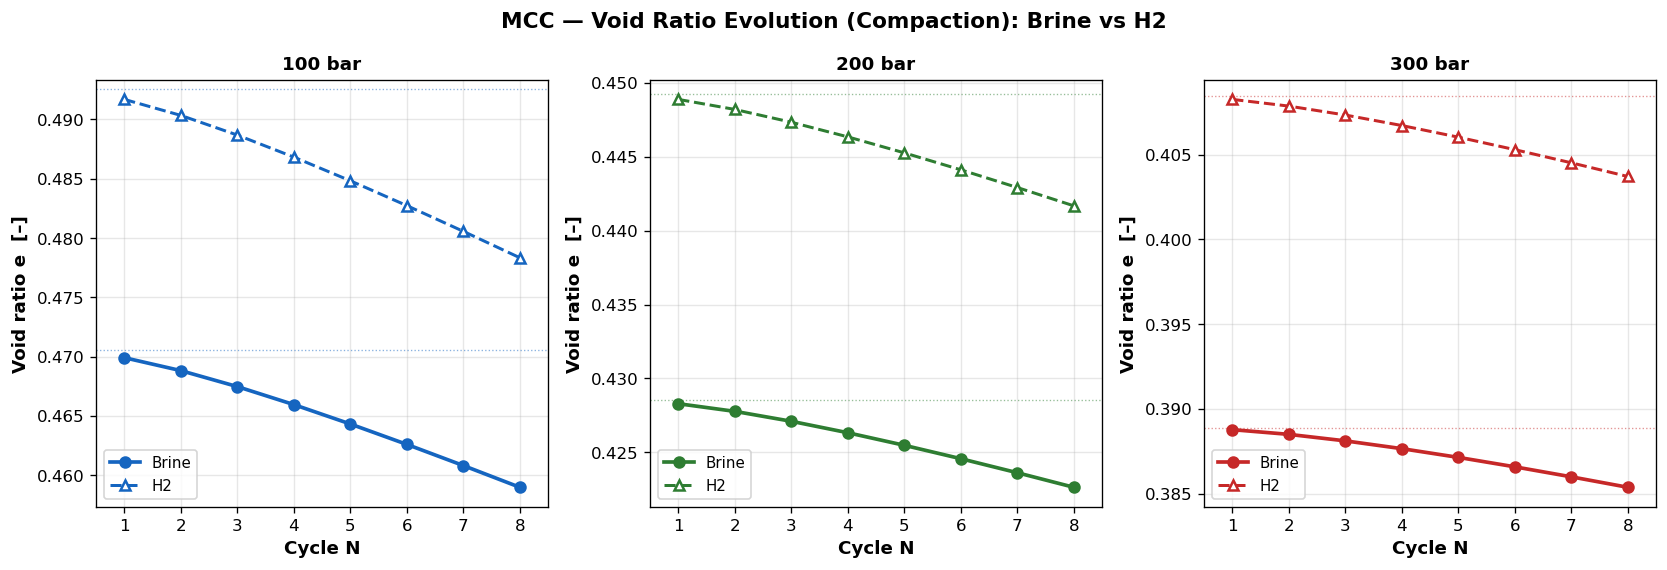

Fig 11 saved (void ratio) ✓


In [29]:
# =============================================================================
# CELL 19 — FIGURE 11: VOID RATIO EVOLUTION (COMPACTION)
# =============================================================================

fig, axes = plt.subplots(1, 3, figsize=(14, 4.8))   # 1×3 layout

for col, p_label in enumerate(PRESSURES):
    ax = axes[col]
    c  = COLOR[p_label]

    for fluid in FLUIDS:
        sim = SIM[(fluid, p_label)]

        ls  = '-'   if fluid == 'Brine' else '--'
        lw  = 2.2   if fluid == 'Brine' else 1.8
        mk  = 'o'   if fluid == 'Brine' else '^'
        mfc = c     if fluid == 'Brine' else 'white'

        # Plot void ratio vs cycle number
        ax.plot(CYC, sim['e_void'], ls + mk, lw=lw, ms=6,
                color=c, mfc=mfc, mew=1.5, label=fluid)

        # Reference dotted line at initial e0
        ax.axhline(sim['e0'], color=c, lw=0.8, ls=':', alpha=0.5)

    ax.set_xlabel('Cycle N')
    ax.set_ylabel('Void ratio e  [–]')
    ax.set_title(f'{p_label}')
    ax.xaxis.set_major_locator(mticker.MultipleLocator(1))
    ax.set_xlim(0.5, 8.5)
    ax.legend(fontsize=9)

fig.suptitle('MCC — Void Ratio Evolution (Compaction): Brine vs H2',
             fontsize=13, fontweight='bold')

plt.tight_layout()
CELL_NAME = "Cell19"
save_fig('Fig11_VoidRatio')
plt.show()
print("Fig 11 saved (void ratio) ✓")


## Cell 20 — Figure 12: Permeability Evolution (Kozeny–Carman)

### What this cell produces
**Fig 12** — Permeability k [mD] vs cycle number, computed from the void ratio using the Kozeny–Carman model.

### Kozeny–Carman equation
$$k = k_{ref} \cdot \frac{e^3}{1+e} \cdot \frac{1+e_0}{e_0^3}$$

### Interpretation
- Permeability **decreases** as void ratio reduces (compaction seals pore throats).
- The grey dashed line marks the reference permeability k₀ = 0.10 mD.
- H₂ cases start with slightly higher permeability (higher φ₀) but converge toward Brine values.
- This information is critical for reservoir simulation of cyclic H₂ storage.

### Saved files
`Cell16_Fig12_Permeability.pdf / .png`


  Saved → Outputs_Cyclic_MCCM_Clay_Rich/Cell20_Fig12_Permeability.pdf
  Saved → Outputs_Cyclic_MCCM_Clay_Rich/Cell20_Fig12_Permeability.png


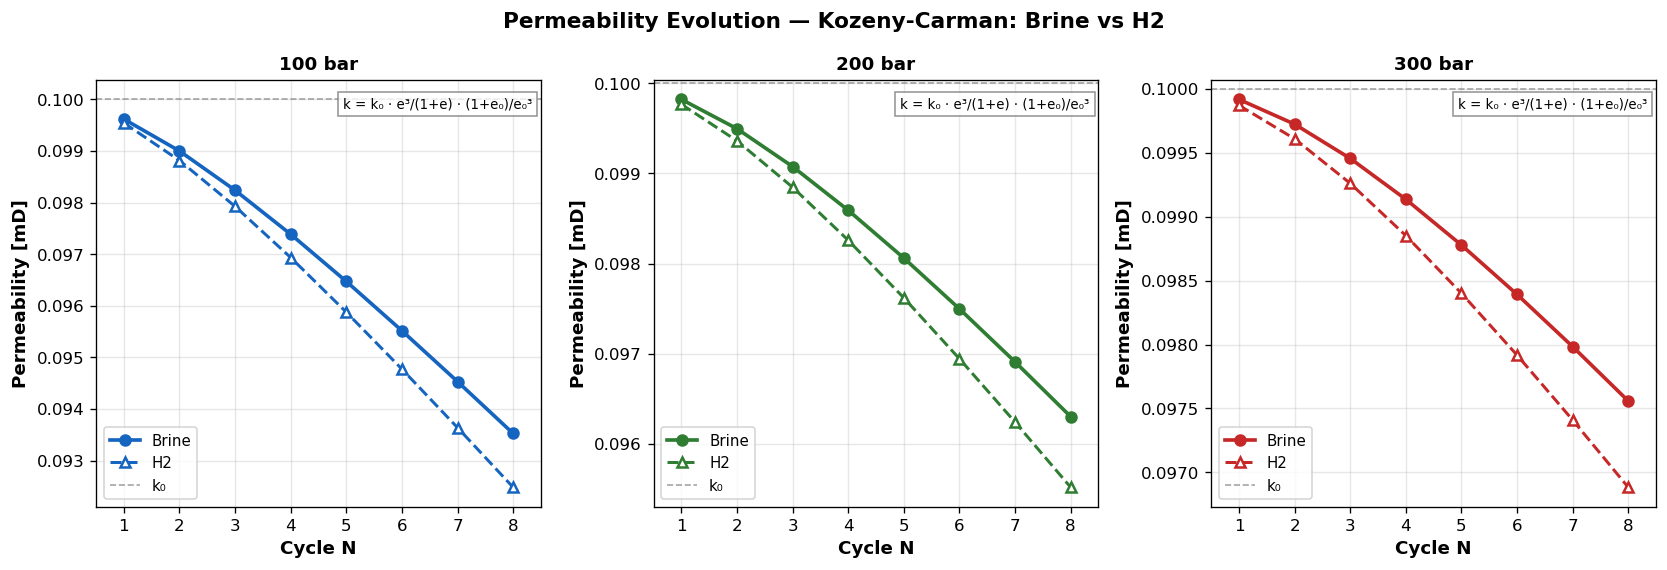

Fig 12 saved (permeability) ✓


In [30]:
# =============================================================================
# CELL 20 — FIGURE 12: PERMEABILITY EVOLUTION (KOZENY-CARMAN)
# =============================================================================

K_REF_mD = 0.10    # reference permeability [mD] (at initial void ratio e0)

fig, axes = plt.subplots(1, 3, figsize=(14, 4.8))   # 1×3 layout

for col, p_label in enumerate(PRESSURES):
    ax = axes[col]
    c  = COLOR[p_label]

    for fluid in FLUIDS:
        sim = SIM[(fluid, p_label)]

        ls  = '-'   if fluid == 'Brine' else '--'
        lw  = 2.2   if fluid == 'Brine' else 1.8
        mk  = 'o'   if fluid == 'Brine' else '^'
        mfc = c     if fluid == 'Brine' else 'white'

        ev = sim['e_void']     # current void ratio array (cycle by cycle)
        e0 = sim['e0']         # initial void ratio

        # Kozeny-Carman: k = k_ref * (e³/(1+e)) / (e0³/(1+e0))
        k_mD = K_REF_mD * (ev**3 / (1.0 + ev)) / (e0**3 / (1.0 + e0))

        ax.plot(CYC, k_mD, ls + mk, lw=lw, ms=6,
                color=c, mfc=mfc, mew=1.5, label=fluid)

    # Reference permeability line
    ax.axhline(K_REF_mD, color='grey', lw=1.0, ls='--', alpha=0.7, label='k₀')

    ax.set_xlabel('Cycle N')
    ax.set_ylabel('Permeability [mD]')
    ax.set_title(f'{p_label}')
    ax.xaxis.set_major_locator(mticker.MultipleLocator(1))
    ax.set_xlim(0.5, 8.5)
    ax.legend(fontsize=9)

    ax.text(0.98, 0.96, r'k = k₀ · e³/(1+e) · (1+e₀)/e₀³',
            transform=ax.transAxes, ha='right', va='top', fontsize=8,
            bbox=dict(fc='white', ec='grey', alpha=0.8, pad=3))

fig.suptitle('Permeability Evolution — Kozeny-Carman: Brine vs H2',
             fontsize=13, fontweight='bold')

plt.tight_layout()
CELL_NAME = "Cell20"
save_fig('Fig12_Permeability')
plt.show()
print("Fig 12 saved (permeability) ✓")


## Cell 21 — Figure 13: All-Cycle q–Accumulated Inelastic Strain Paths

### What this cell produces
**Fig 13** — A 2×3 grid (rows = fluids, columns = pressures) showing the **q vs accumulated |ε_inel|** trajectory for all 8 cycles on each panel.  
Cycle number is encoded by a **coolwarm colormap** (blue = early, red = late).

### Interpretation
- Each curve represents one complete loading–unloading cycle.
- **Rightward shift** of successive curves shows **ratcheting** — permanent strain accumulation.
- **Flatter shape** in later cycles reflects hardening (less strain per q increment).
- Cycles 1, 4, and 8 are labelled for orientation.

### Saved files
`Cell16_Fig13_AllCycle_InelasticStrainPaths.pdf / .png`


  Saved → Outputs_Cyclic_MCCM_Clay_Rich/Cell21_Fig13_AllCycle_InelasticStrainPaths.pdf
  Saved → Outputs_Cyclic_MCCM_Clay_Rich/Cell21_Fig13_AllCycle_InelasticStrainPaths.png


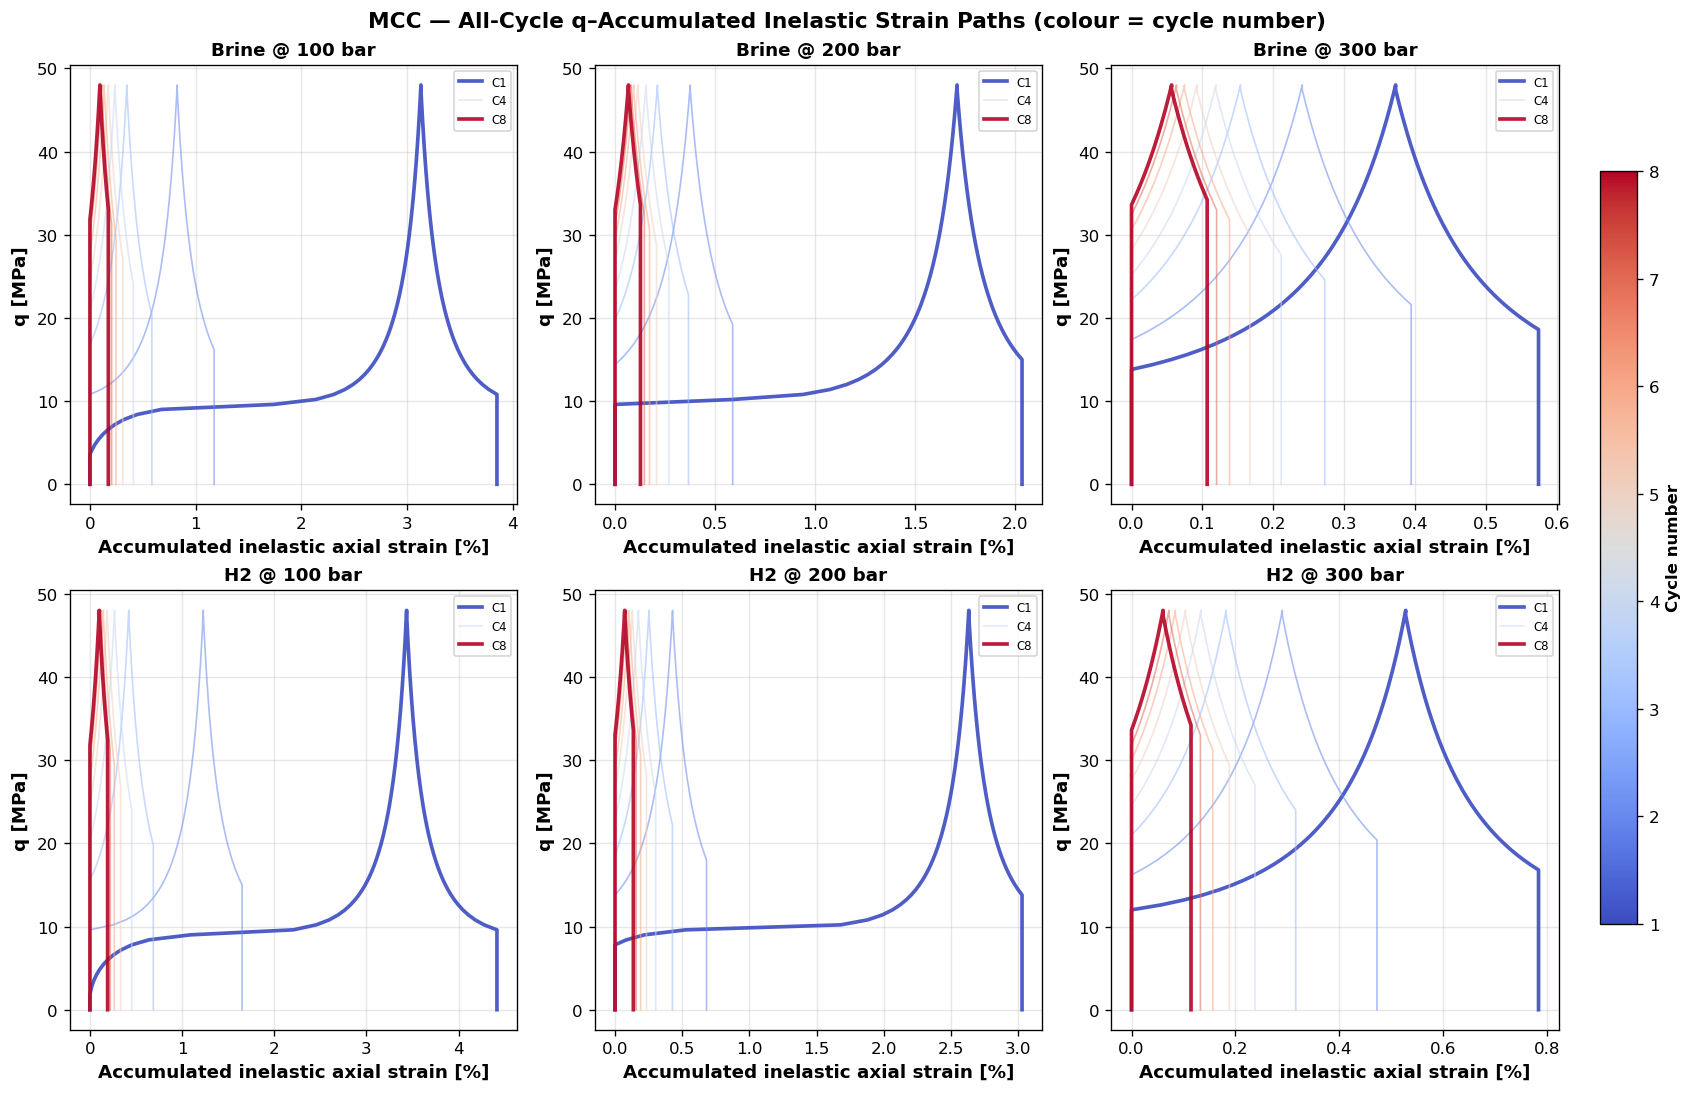

Fig 13 saved ✓


In [31]:
# =============================================================================
# CELL 21 — FIGURE 13: ALL-CYCLE q–ACCUMULATED INELASTIC STRAIN PATHS
# =============================================================================

fig, axes = plt.subplots(2, 3, figsize=(14, 9), constrained_layout=True)  # 2×3 grid

cmap_cyc = plt.cm.coolwarm    # colormap: blue = early cycle, red = late cycle

for row, fluid in enumerate(FLUIDS):
    for col, p_label in enumerate(PRESSURES):
        ax  = axes[row, col]
        sim = SIM[(fluid, p_label)]

        for j, (eps_j, q_j) in enumerate(sim['loops']):
            cc    = cmap_cyc(j / (NCYC - 1))                  # cycle color
            lw_j  = 2.2 if j in [0, NCYC - 1] else 1.0       # highlight C1 and C8
            al_j  = 0.9 if j in [0, NCYC - 1] else 0.55      # stronger alpha for highlights
            lbl   = f'C{j+1}' if j in [0, 3, 7] else ''      # label only 3 cycles

            ax.plot(eps_j * 100, q_j[:len(eps_j)],
                    color=cc, lw=lw_j, alpha=al_j, label=lbl)

        ax.set_xlabel(r'Accumulated inelastic axial strain [%]')
        ax.set_ylabel(Q_LABEL)
        ax.set_title(f'{fluid} @ {p_label}')
        ax.legend(fontsize=7)

# Shared colorbar indicating cycle number
sm = plt.cm.ScalarMappable(cmap=cmap_cyc, norm=plt.Normalize(1, NCYC))
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes, orientation='vertical', shrink=0.78, pad=0.02)
cbar.set_label('Cycle number', fontsize=10)

fig.suptitle('MCC — All-Cycle q–Accumulated Inelastic Strain Paths (colour = cycle number)',
             fontsize=13, fontweight='bold')
CELL_NAME = "Cell21"
save_fig('Fig13_AllCycle_InelasticStrainPaths')
plt.show()
print("Fig 13 saved ✓")


## Cell 22 — Figure 14: All-Cycle q–Signed Inelastic Strain Paths (Clean)

### What this cell produces
**Fig 14** — A 2×3 grid showing **loading and unloading branches separately** using the *signed* inelastic strain from `SIM_SIGNED_CLEAN`.  
Loading branches are plotted with heavier lines; unloading branches are thinner.

### Key difference from Fig 13
Fig 13 uses **absolute** accumulated strain — the loop only moves rightward.  
Fig 14 uses **signed** strain, so the **hysteretic loop** shape (path-reversal during unloading) becomes visible.

### Interpretation
- The loop area is proportional to **energy dissipated per cycle**.
- Small display offsets separate crowded early-cycle curves for visual clarity.
- The colorbar still encodes cycle number (blue → red).

### Saved files
`Cell16_Fig14_AllCycle_SignedStrainPaths_Clean.pdf / .png`


  Saved → Outputs_Cyclic_MCCM_Clay_Rich/Cell22_Fig14_AllCycle_SignedStrainPaths_Clean.pdf
  Saved → Outputs_Cyclic_MCCM_Clay_Rich/Cell22_Fig14_AllCycle_SignedStrainPaths_Clean.png


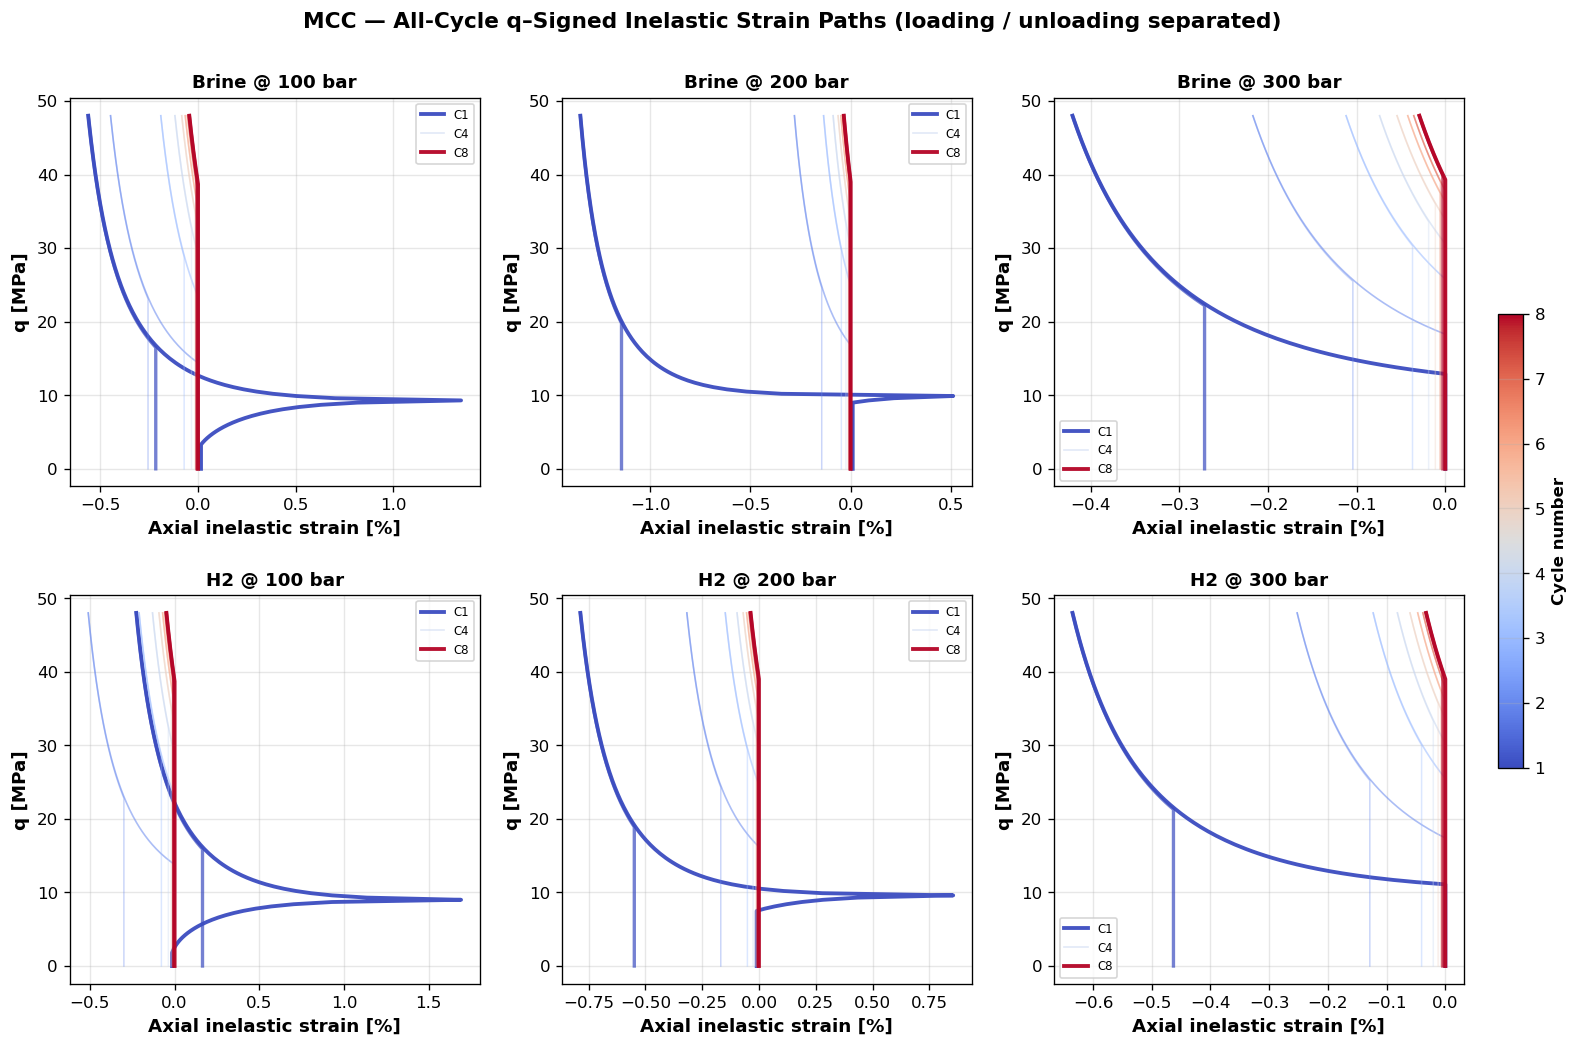

Fig 14 saved ✓


In [32]:
# =============================================================================
# CELL 22 — FIGURE 14: ALL-CYCLE q–SIGNED INELASTIC STRAIN PATHS (CLEAN)
# =============================================================================

fig, axes = plt.subplots(2, 3, figsize=(14, 9))   # 2×3 grid (no constrained_layout)

cmap_cyc = plt.cm.coolwarm    # same colormap as Fig 13

# Tiny display-only horizontal offsets for crowded first-cycle curves
display_shift = {
    ('Brine', '100 bar', 0):  0.015,
    ('Brine', '200 bar', 0):  0.010,
    ('H2',    '100 bar', 0): -0.015,
    ('H2',    '200 bar', 0): -0.010,
}

for row, fluid in enumerate(FLUIDS):
    for col, p_label in enumerate(PRESSURES):
        ax  = axes[row, col]
        sim = SIM_SIGNED_CLEAN[(fluid, p_label)]

        for j, (eps_j, q_j, half_idx) in enumerate(sim['loops']):
            cc          = cmap_cyc(j / (NCYC - 1))
            lw_main     = 2.3  if j in [0, NCYC - 1] else 1.0   # loading branch weight
            lw_unld     = 2.0  if j in [0, NCYC - 1] else 0.9   # unloading branch weight
            alpha_main  = 0.95 if j in [0, NCYC - 1] else 0.55
            alpha_unld  = 0.70 if j in [0, NCYC - 1] else 0.35
            lbl         = f'C{j+1}' if j in [0, 3, 7] else ''

            # Apply tiny horizontal display shift to separate crowded early curves
            x = eps_j * 100.0 + display_shift.get((fluid, p_label, j), 0.0)

            # Plot loading branch (up to turning point)
            ax.plot(x[:half_idx + 1], q_j[:half_idx + 1],
                    color=cc, lw=lw_main, alpha=alpha_main, label=lbl)

            # Plot unloading branch (from turning point to end)
            ax.plot(x[half_idx:], q_j[half_idx:],
                    color=cc, lw=lw_unld, alpha=alpha_unld)

        ax.set_xlabel(r'Axial inelastic strain [%]')
        ax.set_ylabel(Q_LABEL)
        ax.set_title(f'{fluid} @ {p_label}')
        ax.legend(fontsize=7)

# Manually set subplot margins to leave room for colorbar on the right
plt.subplots_adjust(left=0.07, right=0.90, bottom=0.08, top=0.90,
                    wspace=0.20, hspace=0.28)

# External fixed colorbar axis
sm  = plt.cm.ScalarMappable(cmap=cmap_cyc, norm=plt.Normalize(1, NCYC))
sm.set_array([])
cax = fig.add_axes([0.92, 0.28, 0.015, 0.42])   # [left, bottom, width, height]
cbar = fig.colorbar(sm, cax=cax, orientation='vertical')
cbar.set_label('Cycle number', fontsize=10)

fig.suptitle('MCC — All-Cycle q–Signed Inelastic Strain Paths (loading / unloading separated)',
             fontsize=13, fontweight='bold')
CELL_NAME = "Cell22"
save_fig('Fig14_AllCycle_SignedStrainPaths_Clean')
plt.show()
print("Fig 14 saved ✓")


## Cell 23 — Figure 15: Hardening Locus — Yield Surface Expansion Cycle by Cycle

### What this cell produces
**Fig 15** — A 2×3 grid in which **each yield surface for cycles 1–8** is plotted in sequence, colored by cycle number with the **viridis colormap** (purple = early, yellow = late).

### Interpretation
- The **progressive outward expansion** of the ellipses is the geometric representation of isotropic hardening.
- The initial grey dashed ellipse is the reference state (Cycle 0 = p_c0).
- The black stress path is overlaid to show its position relative to the evolving elastic domain.
- At higher pressures the rate of expansion is larger (more compaction per cycle).

### Saved files
`Cell16_Fig15_HardeningLocus.pdf / .png`


  Saved → Outputs_Cyclic_MCCM_Clay_Rich/Cell23_Fig15_HardeningLocus.pdf
  Saved → Outputs_Cyclic_MCCM_Clay_Rich/Cell23_Fig15_HardeningLocus.png


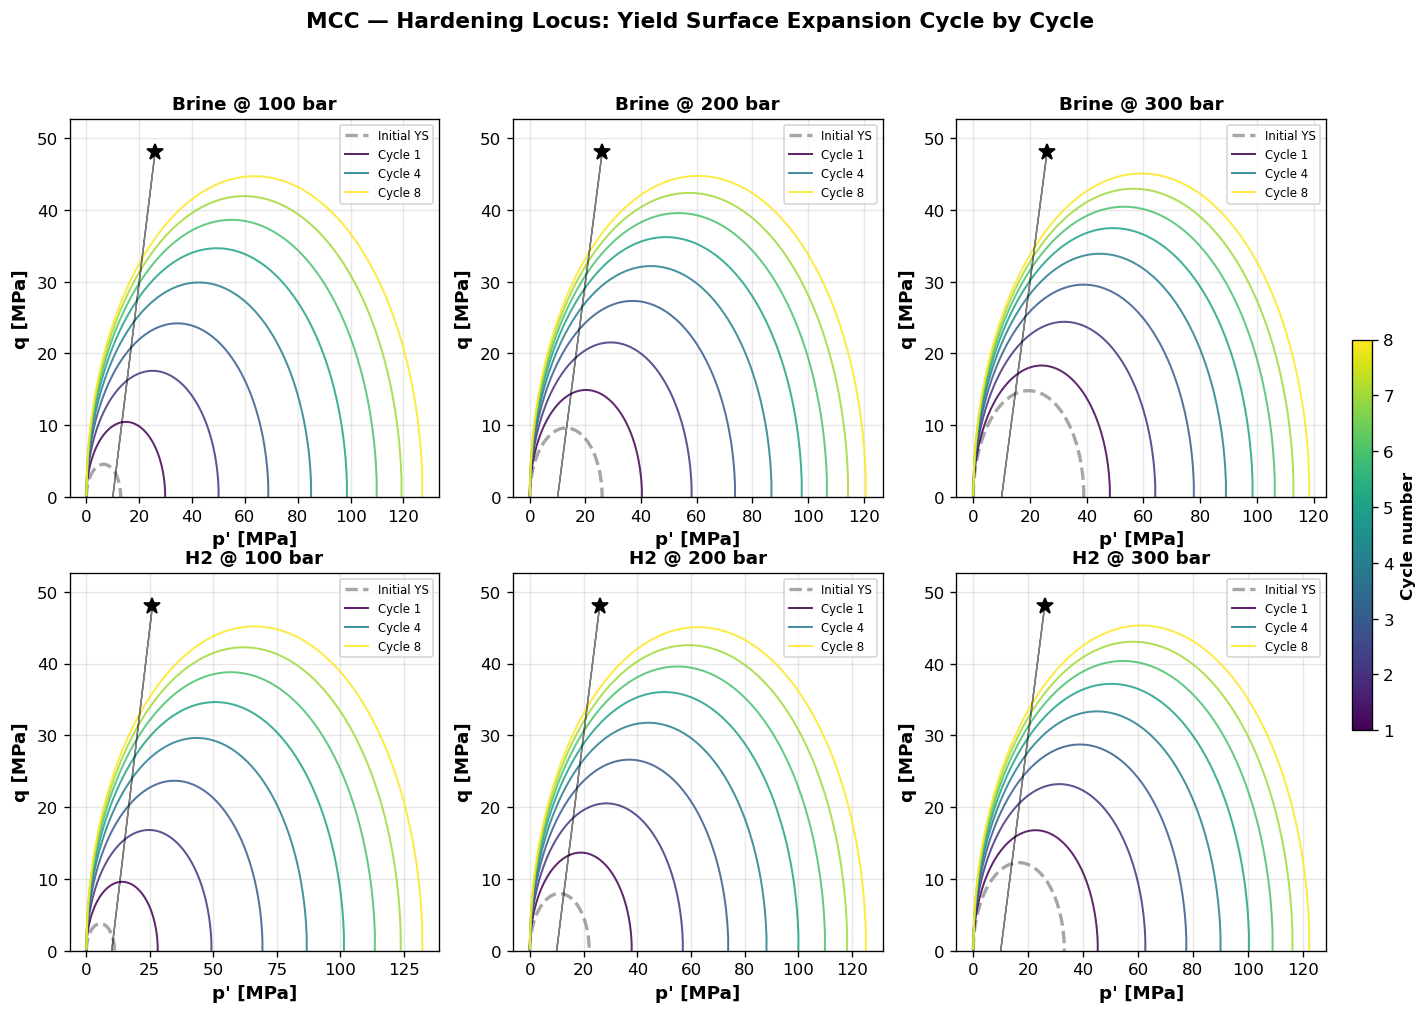

Fig 15 saved (hardening locus) ✓


In [33]:
# =============================================================================
# CELL 23 — FIGURE 15: HARDENING LOCUS — YIELD SURFACE EXPANSION CYCLE BY CYCLE
# =============================================================================

fig, axes = plt.subplots(2, 3, figsize=(14, 9))   # 2×3 grid

cmap_hl = plt.cm.viridis    # colormap: purple = early cycle, yellow = late cycle

for row, fluid in enumerate(FLUIDS):
    for col, p_label in enumerate(PRESSURES):
        ax  = axes[row, col]
        sim = SIM[(fluid, p_label)]

        # Initial yield surface (reference, grey dashed)
        py0, qy0 = mcc_yield_surface(sim['pc0'], sim['M'])
        ax.plot(py0, qy0, '--', lw=2.0, color='grey', alpha=0.7,
                label='Initial YS')

        # Yield surfaces for each cycle (colored by cycle number)
        for j in range(NCYC):
            pyj, qyj = mcc_yield_surface(sim['pc_cyc'][j], sim['M'])
            cc  = cmap_hl(j / (NCYC - 1))          # cycle color
            lbl = f'Cycle {j+1}' if j in [0, 3, 7] else ''   # label 3 cycles only

            ax.plot(pyj, qyj, '-', lw=1.2, color=cc, alpha=0.85, label=lbl)

        # Stress path overlay
        ax.plot(PP_SP,             QP_SP,             'k-', lw=0.9, alpha=0.5)
        ax.plot(PP_SP[HALF_SP],    QP_SP[HALF_SP],    'k*', ms=10)   # peak marker

        ax.set_xlabel(PDASH_LABEL)
        ax.set_ylabel(Q_LABEL)
        ax.set_title(f'{fluid} @ {p_label}')
        ax.set_ylim(bottom=0)
        ax.legend(fontsize=7)

# Shared colorbar indicating cycle number
sm2 = plt.cm.ScalarMappable(cmap=cmap_hl, norm=plt.Normalize(1, NCYC))
sm2.set_array([])
cbar2 = fig.colorbar(sm2, ax=axes, orientation='vertical',
                      fraction=0.015, pad=0.02)
cbar2.set_label('Cycle number', fontsize=10)

fig.suptitle('MCC — Hardening Locus: Yield Surface Expansion Cycle by Cycle',
             fontsize=13, fontweight='bold')
CELL_NAME = "Cell23"
save_fig('Fig15_HardeningLocus')
plt.show()
print("Fig 15 saved (hardening locus) ✓")


## Cell 24 — Summary Table & Figure Index

### What this cell produces
A printed summary of:
1. **All figure files saved** to `Outputs_Cyclic_MCCM_Clay_Rich/`
2. **Numerical results** table: cumulative strain, final p_c, void ratio, and normalised permeability k/k₀ for all six cases.

### No figures are produced here.


In [34]:
# =============================================================================
# CELL 24 — SUMMARY TABLE & FIGURE INDEX
# =============================================================================

# ── Figure index ──────────────────────────────────────────────────────────────
print()
print("=" * 72)
print("  Figures saved to:", OUTPUT_DIR)
print("=" * 72)

# List of all figures produced in this notebook
fig_index = [
    "Cell09_Fig01  Yield surfaces only (initial state)",
    "Cell10_Fig02  Yield surfaces + prescribed stress path",
    "Cell11_Fig03  Brine + H2 unified yield surfaces",
    "Cell12_Fig04  Cyclic stress path + evolving YS (Brine)",
    "Cell12_Fig04  Cyclic stress path + evolving YS (H2)",
    "Cell13_Fig05  Cyclic stress path: Brine + H2 together",
    "Cell14_Fig06  Single-cycle loop (Brine)",
    "Cell14_Fig06  Single-cycle loop (H2)",
    "Cell15_Fig07  Single-cycle loop: Brine + H2 together",
    "Cell16_Fig08  Cumulative inelastic strain (all cases)",
    "Cell17_Fig09  Per-cycle strain increments",
    "Cell18_Fig10  Preconsolidation pressure p_c evolution",
    "Cell19_Fig11  Void ratio evolution (compaction)",
    "Cell20_Fig12  Permeability evolution (Kozeny-Carman)",
    "Cell21_Fig13  All-cycle q–accumulated inelastic strain paths",
    "Cell22_Fig14  All-cycle q–signed inelastic strain paths (clean)",
    "Cell23_Fig15  Hardening locus: yield surface expansion cycle by cycle",
]

for f in fig_index:                # print each figure entry
    print(f"  {f}")

# ── Numerical results summary table ───────────────────────────────────────────
print()
print("=" * 72)
print("  Numerical results summary (end of 8 cycles)")
print("=" * 72)
print(f"  {'Case':<22} {'e_cum [%]':>10} {'pc_final [MPa]':>14} {'e_void':>8} {'k/k0':>7}")
print("  " + "─" * 64)

for fluid, p_label in CASES:
    sim = SIM[(fluid, p_label)]       # read simulation results

    e0  = sim['e0']                   # initial void ratio
    ev  = sim['e_void'][-1]           # final void ratio (after 8 cycles)

    # Kozeny-Carman permeability ratio: k/k0 = (e³/(1+e)) / (e0³/(1+e0))
    kr  = (ev**3 / (1.0 + ev)) / (e0**3 / (1.0 + e0))

    print(f"  {fluid + ' ' + p_label:<22} "
          f"{sim['e_cum'][-1] * 100:>10.4f} "    # cumulative strain [%]
          f"{sim['pc_cyc'][-1]:>14.3f} "          # final pc [MPa]
          f"{ev:>8.5f} "                           # final void ratio
          f"{kr:>7.4f}")                           # normalised permeability

print("=" * 72)
print("\nAll done. ✓")



  Figures saved to: Outputs_Cyclic_MCCM_Clay_Rich
  Cell09_Fig01  Yield surfaces only (initial state)
  Cell10_Fig02  Yield surfaces + prescribed stress path
  Cell11_Fig03  Brine + H2 unified yield surfaces
  Cell12_Fig04  Cyclic stress path + evolving YS (Brine)
  Cell12_Fig04  Cyclic stress path + evolving YS (H2)
  Cell13_Fig05  Cyclic stress path: Brine + H2 together
  Cell14_Fig06  Single-cycle loop (Brine)
  Cell14_Fig06  Single-cycle loop (H2)
  Cell15_Fig07  Single-cycle loop: Brine + H2 together
  Cell16_Fig08  Cumulative inelastic strain (all cases)
  Cell17_Fig09  Per-cycle strain increments
  Cell18_Fig10  Preconsolidation pressure p_c evolution
  Cell19_Fig11  Void ratio evolution (compaction)
  Cell20_Fig12  Permeability evolution (Kozeny-Carman)
  Cell21_Fig13  All-cycle q–accumulated inelastic strain paths
  Cell22_Fig14  All-cycle q–signed inelastic strain paths (clean)
  Cell23_Fig15  Hardening locus: yield surface expansion cycle by cycle

  Numerical results summa